# 🎓 MODÈLE 1 — CLUSTERING : SEGMENTATION DES ÉTUDIANTS
## Plateforme EnglishForU — Machine Learning Appliqué
### Année Universitaire 2025–2026 | ESPRIT

---

## 📌 Introduction

Ce notebook a pour objectif de **segmenter les étudiants** inscrits sur la plateforme d'apprentissage de l'anglais **EnglishForU** selon leur comportement, leur engagement et leurs performances académiques.

### 🎯 Objectif Métier (BO)
> **Augmenter l'engagement moyen des étudiants de 20%** en identifiant différents profils comportementaux pour adapter les parcours pédagogiques.

### 🔬 Objectif Data Science (DSO)
> Appliquer des **techniques de clustering (segmentation non supervisée)** pour identifier automatiquement des groupes homogènes d'étudiants, puis valider ces clusters via des algorithmes de **classification supervisée** avec évaluation complète.

### 📊 Algorithmes appliqués

| Phase | Algorithme | Rôle |
|-------|-----------|------|
| **Clustering** | K-Means | Partitionnement centroïde |
| **Clustering** | DBSCAN | Détection par densité |
| **Clustering** | Agglomerative Clustering | Hiérarchique ascendant |
| **Clustering** | Gaussian Mixture Model | Probabiliste |
| **Classification** | Decision Tree | Arbre de décision |
| **Classification** | Random Forest | Forêt aléatoire |
| **Classification** | SVM | Support Vector Machine |
| **Classification** | XGBoost | Gradient Boosting |

### 🗂️ Features utilisées
- **Comportementales** : `attendance_rate`, `login_frequency_per_week`, `time_spent_hours_per_week`, `days_since_last_login`
- **Académiques** : `avg_test_score`, `engagement_score`, `course_completion_rate`, `assignment_submission_rate`, `video_watch_percentage`
- **Engineered** : `performance_index`, `activity_ratio`, `risk_score`, `student_value`, `engagement_level_num`

---

## 📦 1. Import des Librairies

In [2]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Métriques de clustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)

# Classification supervisée (validation des clusters)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)

# XGBoost
!pip install xgboost
from xgboost import XGBClassifier


# Dendrogramme
from scipy.cluster.hierarchy import dendrogram, linkage

# Style global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#8B0000', '#C0392B', '#E74C3C', '#F1948A', '#FADBD8', '#2C3E50', '#3498DB', '#27AE60']
PALETTE = sns.color_palette(COLORS)

print("✅ Toutes les librairies sont importées avec succès !")


✅ Toutes les librairies sont importées avec succès !


## 📂 2. Chargement du Dataset Clean

In [4]:
# ============================================================
# CHARGEMENT DU DATASET
# ============================================================
df = pd.read_excel('dataset_clean-1.xlsx')

print(f"📊 Dimensions du dataset : {df.shape}")
print(f"📋 Colonnes ({len(df.columns)}) : {list(df.columns)}")
print("\n")
df.head()

📊 Dimensions du dataset : (3150, 28)
📋 Colonnes (28) : ['student_id', 'age', 'gender', 'english_level', 'attendance_rate', 'avg_test_score', 'engagement_score', 'login_frequency_per_week', 'time_spent_hours_per_week', 'package_type', 'package_price', 'package_duration_months', 'total_payments', 'churn_risk', 'academic_success', 'profession', 'income_level', 'city', 'registration_channel', 'days_since_last_login', 'course_completion_rate', 'assignment_submission_rate', 'video_watch_percentage', 'discount_used', 'payment_delay_days', 'upgrade_history', 'churn', 'lifetime_value']




,student_id,age,gender,english_level,attendance_rate,avg_test_score,engagement_score,login_frequency_per_week,time_spent_hours_per_week,package_type,...,registration_channel,days_since_last_login,course_completion_rate,assignment_submission_rate,video_watch_percentage,discount_used,payment_delay_days,upgrade_history,churn,lifetime_value
0,1,54,Female,Beginner,0.94,75.98,0.57,1,11.79,Basic,...,Facebook,20,0.41,0.57,0.61,0,24,4,0,1646
1,2,44,Female,Intermediate,0.91,50.65,0.97,12,19.98,Standard,...,Facebook,15,0.59,0.78,0.82,0,0,4,0,1754
2,3,30,Male,Intermediate,0.65,58.22,0.49,2,19.11,Basic,...,Facebook,14,0.88,0.51,0.69,0,9,0,0,928
3,4,23,Male,Intermediate,0.47,60.21,0.95,11,13.45,Standard,...,Referral,53,0.76,0.58,0.74,0,24,2,0,1356
4,5,36,Male,Beginner,0.45,74.07,0.11,11,9.83,Standard,...,Instagram,56,0.58,0.69,0.92,0,29,3,1,1098


In [26]:
# ============================================================
# INFORMATIONS GÉNÉRALES
# ============================================================
print("📌 Types de données :")
print(df.dtypes)
print("\n📌 Valeurs manquantes :")
print(df.isnull().sum())
print("\n📌 Statistiques descriptives :")
df.describe().round(2)

📌 Types de données :
student_id                      int64
age                             int64
gender                         object
english_level                  object
attendance_rate               float64
avg_test_score                float64
engagement_score              float64
login_frequency_per_week        int64
time_spent_hours_per_week     float64
package_type                   object
package_price                   int64
package_duration_months         int64
total_payments                  int64
churn_risk                      int64
academic_success                int64
profession                     object
income_level                   object
city                           object
registration_channel           object
days_since_last_login           int64
course_completion_rate        float64
assignment_submission_rate    float64
video_watch_percentage        float64
discount_used                   int64
payment_delay_days              int64
upgrade_history              

,student_id,age,attendance_rate,avg_test_score,engagement_score,login_frequency_per_week,time_spent_hours_per_week,package_price,package_duration_months,total_payments,...,academic_success,days_since_last_login,course_completion_rate,assignment_submission_rate,video_watch_percentage,discount_used,payment_delay_days,upgrade_history,churn,lifetime_value
count,3150.00,3150.00,3150.00,3150.00,3150.00,3150.00,3150.00,3150.00,3150.00,3150.00,...,3150.00,3150.00,3150.00,3150.00,3150.00,3150.00,3150.00,3150.00,3150.00,3150.00
mean,1502.85,35.90,0.70,68.33,0.50,7.38,10.28,434.70,5.57,2462.79,...,0.25,29.64,0.65,0.70,0.75,0.31,14.70,2.03,0.24,1201.32
std,865.84,11.38,0.16,18.89,0.27,4.01,5.52,207.05,4.13,2359.18,...,0.43,17.32,0.20,0.17,0.14,0.46,8.61,1.41,0.43,429.87
min,1.00,18.00,0.40,0.00,0.00,1.00,0.00,200.00,1.00,200.00,...,0.00,0.00,0.30,0.40,0.50,0.00,0.00,0.00,0.00,180.00
25%,757.25,26.00,0.57,55.73,0.28,4.00,5.63,200.00,3.00,600.00,...,0.00,15.00,0.48,0.55,0.62,0.00,7.00,1.00,0.00,890.00
50%,1504.50,36.00,0.70,69.21,0.49,7.00,10.26,400.00,6.00,1650.00,...,0.00,29.00,0.65,0.70,0.75,0.00,15.00,2.00,0.00,1196.00
75%,2250.00,46.00,0.84,82.44,0.71,11.00,15.00,700.00,12.00,4200.00,...,1.00,45.00,0.82,0.84,0.87,1.00,22.00,3.00,0.00,1552.00
max,3000.00,55.00,1.00,99.98,1.00,14.00,19.99,700.00,12.00,8400.00,...,1.00,59.00,1.00,1.00,1.00,1.00,29.00,4.00,1.00,2000.00


## 🔧 3. Feature Engineering — Création de Nouvelles Variables

> Nous créons de nouvelles features pour mieux capturer le comportement des étudiants.

In [6]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# 1. Performance Index : synthèse académique (score + assiduité + complétion)
df['performance_index'] = (
    (df['avg_test_score'] / 100) + 
    df['attendance_rate'] + 
    df['course_completion_rate']
) / 3

# 2. Activity Ratio : densité d'utilisation (connexions par heure)
df['activity_ratio'] = df['login_frequency_per_week'] / (df['time_spent_hours_per_week'] + 0.001)

# 3. Risk Score : risque de churn basé sur l'inactivité et le faible engagement
df['risk_score'] = df['days_since_last_login'] * (1 - df['engagement_score'])

# 4. Student Value : valeur mensuelle de l'étudiant
if 'total_payments' in df.columns and 'package_duration_months' in df.columns:
    df['student_value'] = df['total_payments'] / (df['package_duration_months'] + 0.001)
else:
    df['student_value'] = df.get('lifetime_value', 0) / 12

# 5. Engagement Level (catégoriel → numérique)
def categorize_engagement(score):
    if score < 0.33:
        return 0  # Faible
    elif score < 0.66:
        return 1  # Moyen
    else:
        return 2  # Élevé

df['engagement_level_num'] = df['engagement_score'].apply(categorize_engagement)

# 6. Learning Efficiency : ratio score / temps investi
df['learning_efficiency'] = df['avg_test_score'] / (df['time_spent_hours_per_week'] + 0.001)

# 7. Content Engagement : engagement contenu (vidéo + devoirs + cours)
df['content_engagement'] = (
    df['video_watch_percentage'] + 
    df['assignment_submission_rate'] + 
    df['course_completion_rate']
) / 3

print("✅ Nouvelles colonnes créées :")
new_cols = ['performance_index', 'activity_ratio', 'risk_score', 
            'student_value', 'engagement_level_num', 'learning_efficiency', 'content_engagement']
print(df[new_cols].describe().round(3))

✅ Nouvelles colonnes créées :
       performance_index  activity_ratio  risk_score  student_value  \
count           3150.000        3150.000    3150.000       3150.000   
mean               0.678         143.651      14.892        434.533   
std                0.108        1150.477      12.701        206.978   
min                0.273           0.050       0.000        199.800   
25%                0.605           0.374       4.072        199.967   
50%                0.679           0.725      11.880        399.867   
75%                0.754           1.363      22.950        699.767   
max                0.979       14000.000      57.420        699.942   

       engagement_level_num  learning_efficiency  content_engagement  
count              3150.000             3150.000            3150.000  
mean                  1.009             1316.060               0.699  
std                   0.773             9548.961               0.100  
min                   0.000                0.0

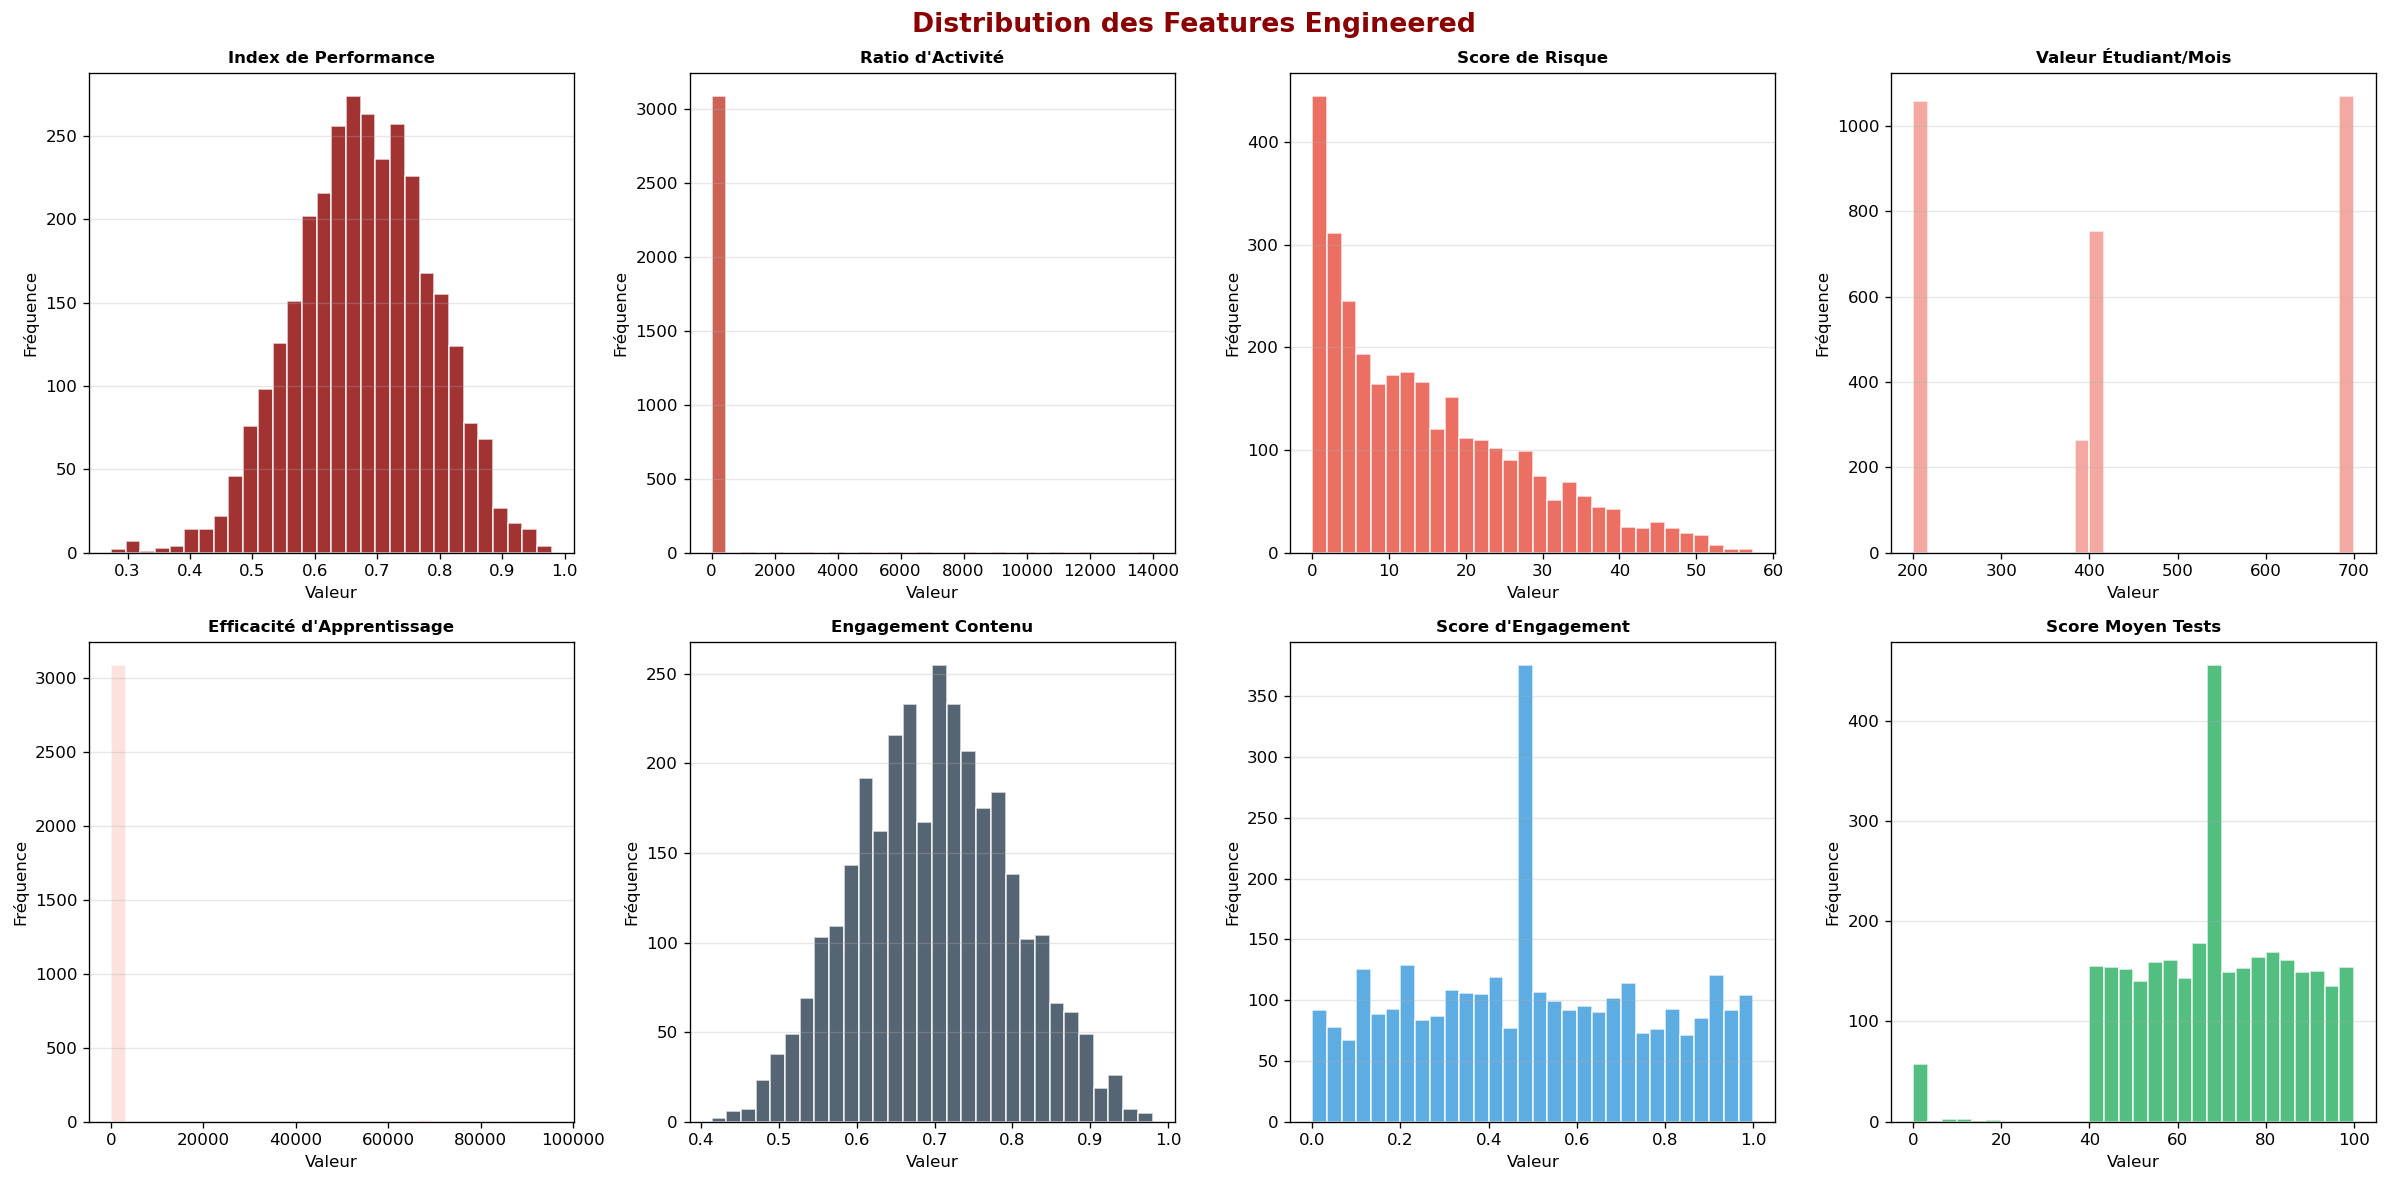

📊 Distribution des features affichée


In [8]:
# ============================================================
# VISUALISATION DES NOUVELLES FEATURES
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Distribution des Features Engineered', fontsize=16, fontweight='bold', color='#8B0000')

features_to_plot = [
    ('performance_index', 'Index de Performance'),
    ('activity_ratio', 'Ratio d\'Activité'),
    ('risk_score', 'Score de Risque'),
    ('student_value', 'Valeur Étudiant/Mois'),
    ('learning_efficiency', 'Efficacité d\'Apprentissage'),
    ('content_engagement', 'Engagement Contenu'),
    ('engagement_score', 'Score d\'Engagement'),
    ('avg_test_score', 'Score Moyen Tests'),
]

for i, (feat, title) in enumerate(features_to_plot):
    ax = axes[i//4, i%4]
    ax.hist(df[feat].dropna(), bins=30, color=COLORS[i % len(COLORS)], edgecolor='white', alpha=0.8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()
print("📊 Distribution des features affichée")

## ⚙️ 4. Préparation des Données pour le Clustering

In [10]:
# ============================================================
# SÉLECTION DES FEATURES POUR LE CLUSTERING
# ============================================================
FEATURES = [
    # Comportement
    'attendance_rate',
    'login_frequency_per_week',
    'time_spent_hours_per_week',
    'days_since_last_login',
    # Académique
    'avg_test_score',
    'engagement_score',
    'course_completion_rate',
    'assignment_submission_rate',
    'video_watch_percentage',
    # Engineered
    'performance_index',
    'activity_ratio',
    'risk_score',
    'content_engagement',
    'learning_efficiency'
]

# Vérification des colonnes disponibles
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"✅ Features sélectionnées ({len(FEATURES)}) : {FEATURES}")

X = df[FEATURES].copy()
X = X.fillna(X.median())

# Normalisation StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n📐 Shape de X_scaled : {X_scaled.shape}")
print("✅ Normalisation StandardScaler appliquée")

✅ Features sélectionnées (14) : ['attendance_rate', 'login_frequency_per_week', 'time_spent_hours_per_week', 'days_since_last_login', 'avg_test_score', 'engagement_score', 'course_completion_rate', 'assignment_submission_rate', 'video_watch_percentage', 'performance_index', 'activity_ratio', 'risk_score', 'content_engagement', 'learning_efficiency']

📐 Shape de X_scaled : (3150, 14)
✅ Normalisation StandardScaler appliquée


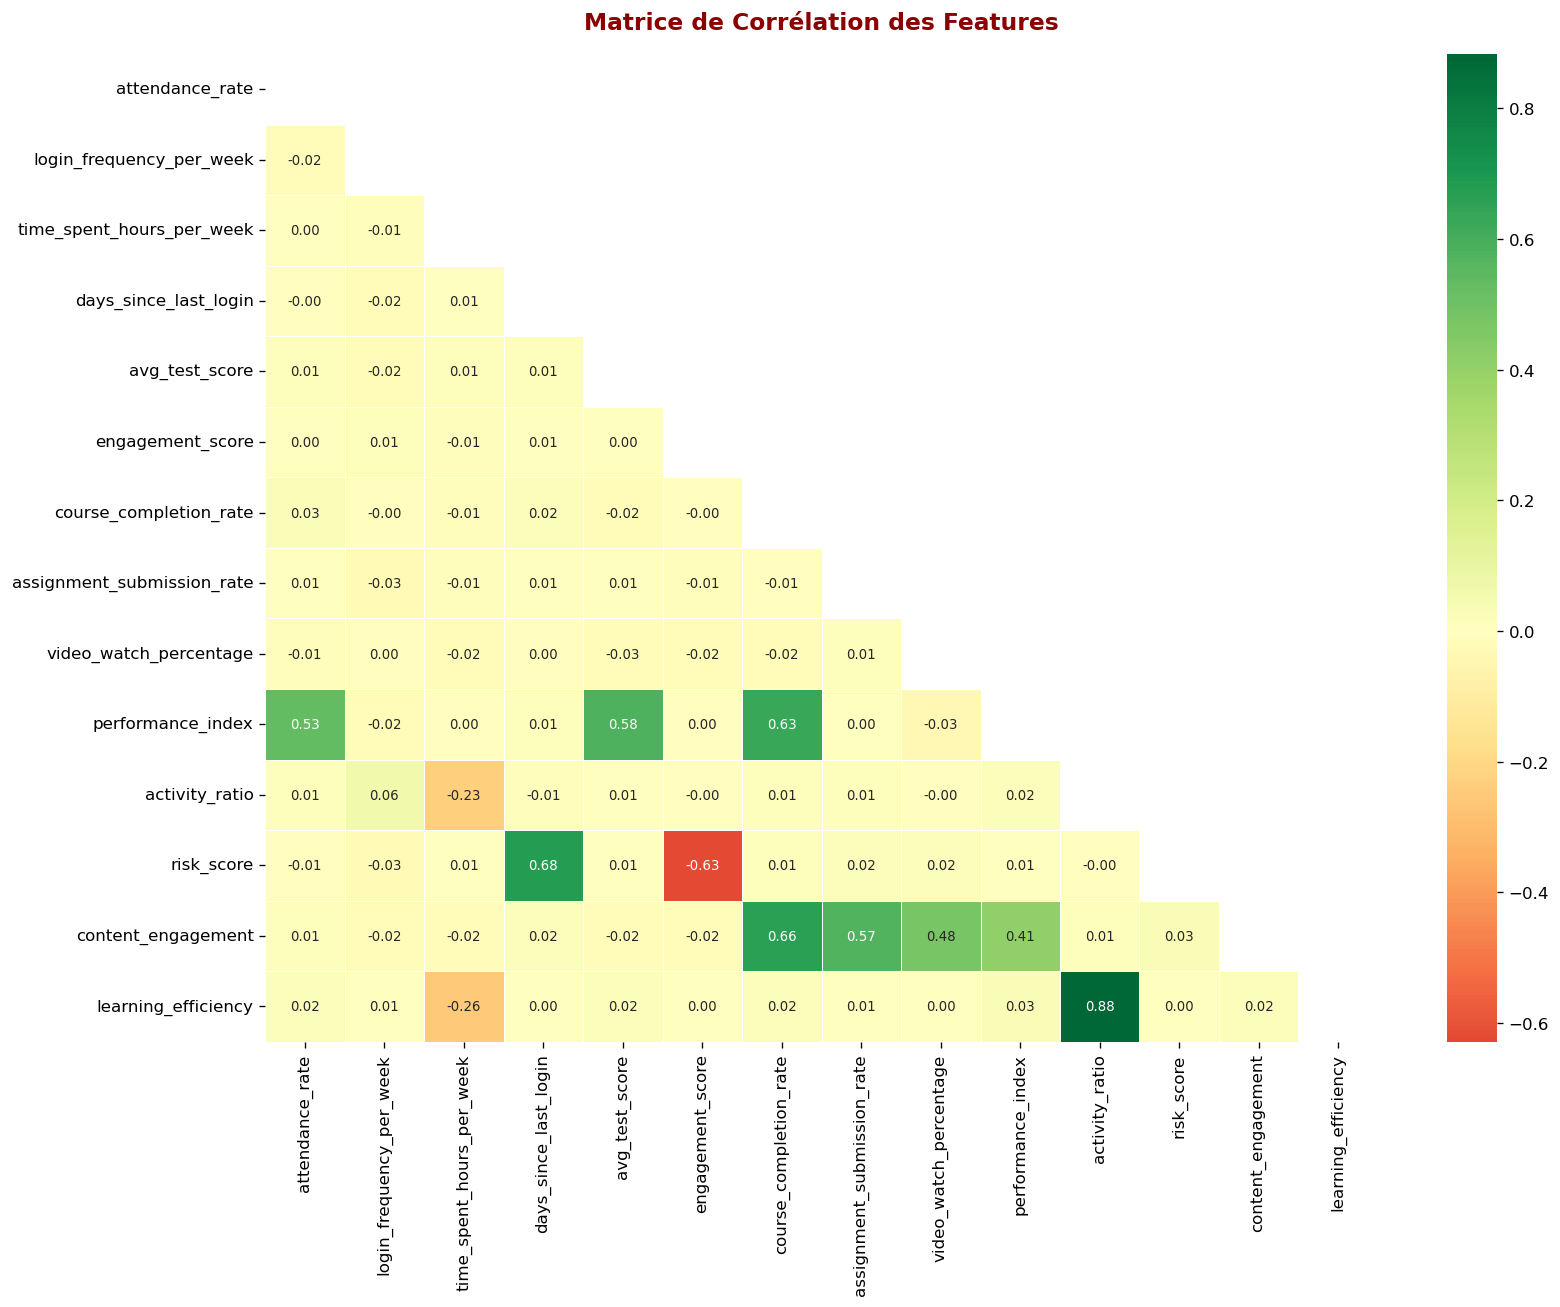

In [12]:
# ============================================================
# MATRICE DE CORRÉLATION
# ============================================================
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax, linewidths=0.5,
    annot_kws={'size': 8}
)
ax.set_title('Matrice de Corrélation des Features', fontsize=14, fontweight='bold', color='#8B0000', pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

## 🔍 5. Détermination du Nombre Optimal de Clusters

### Méthode du Coude (Elbow) + Score de Silhouette

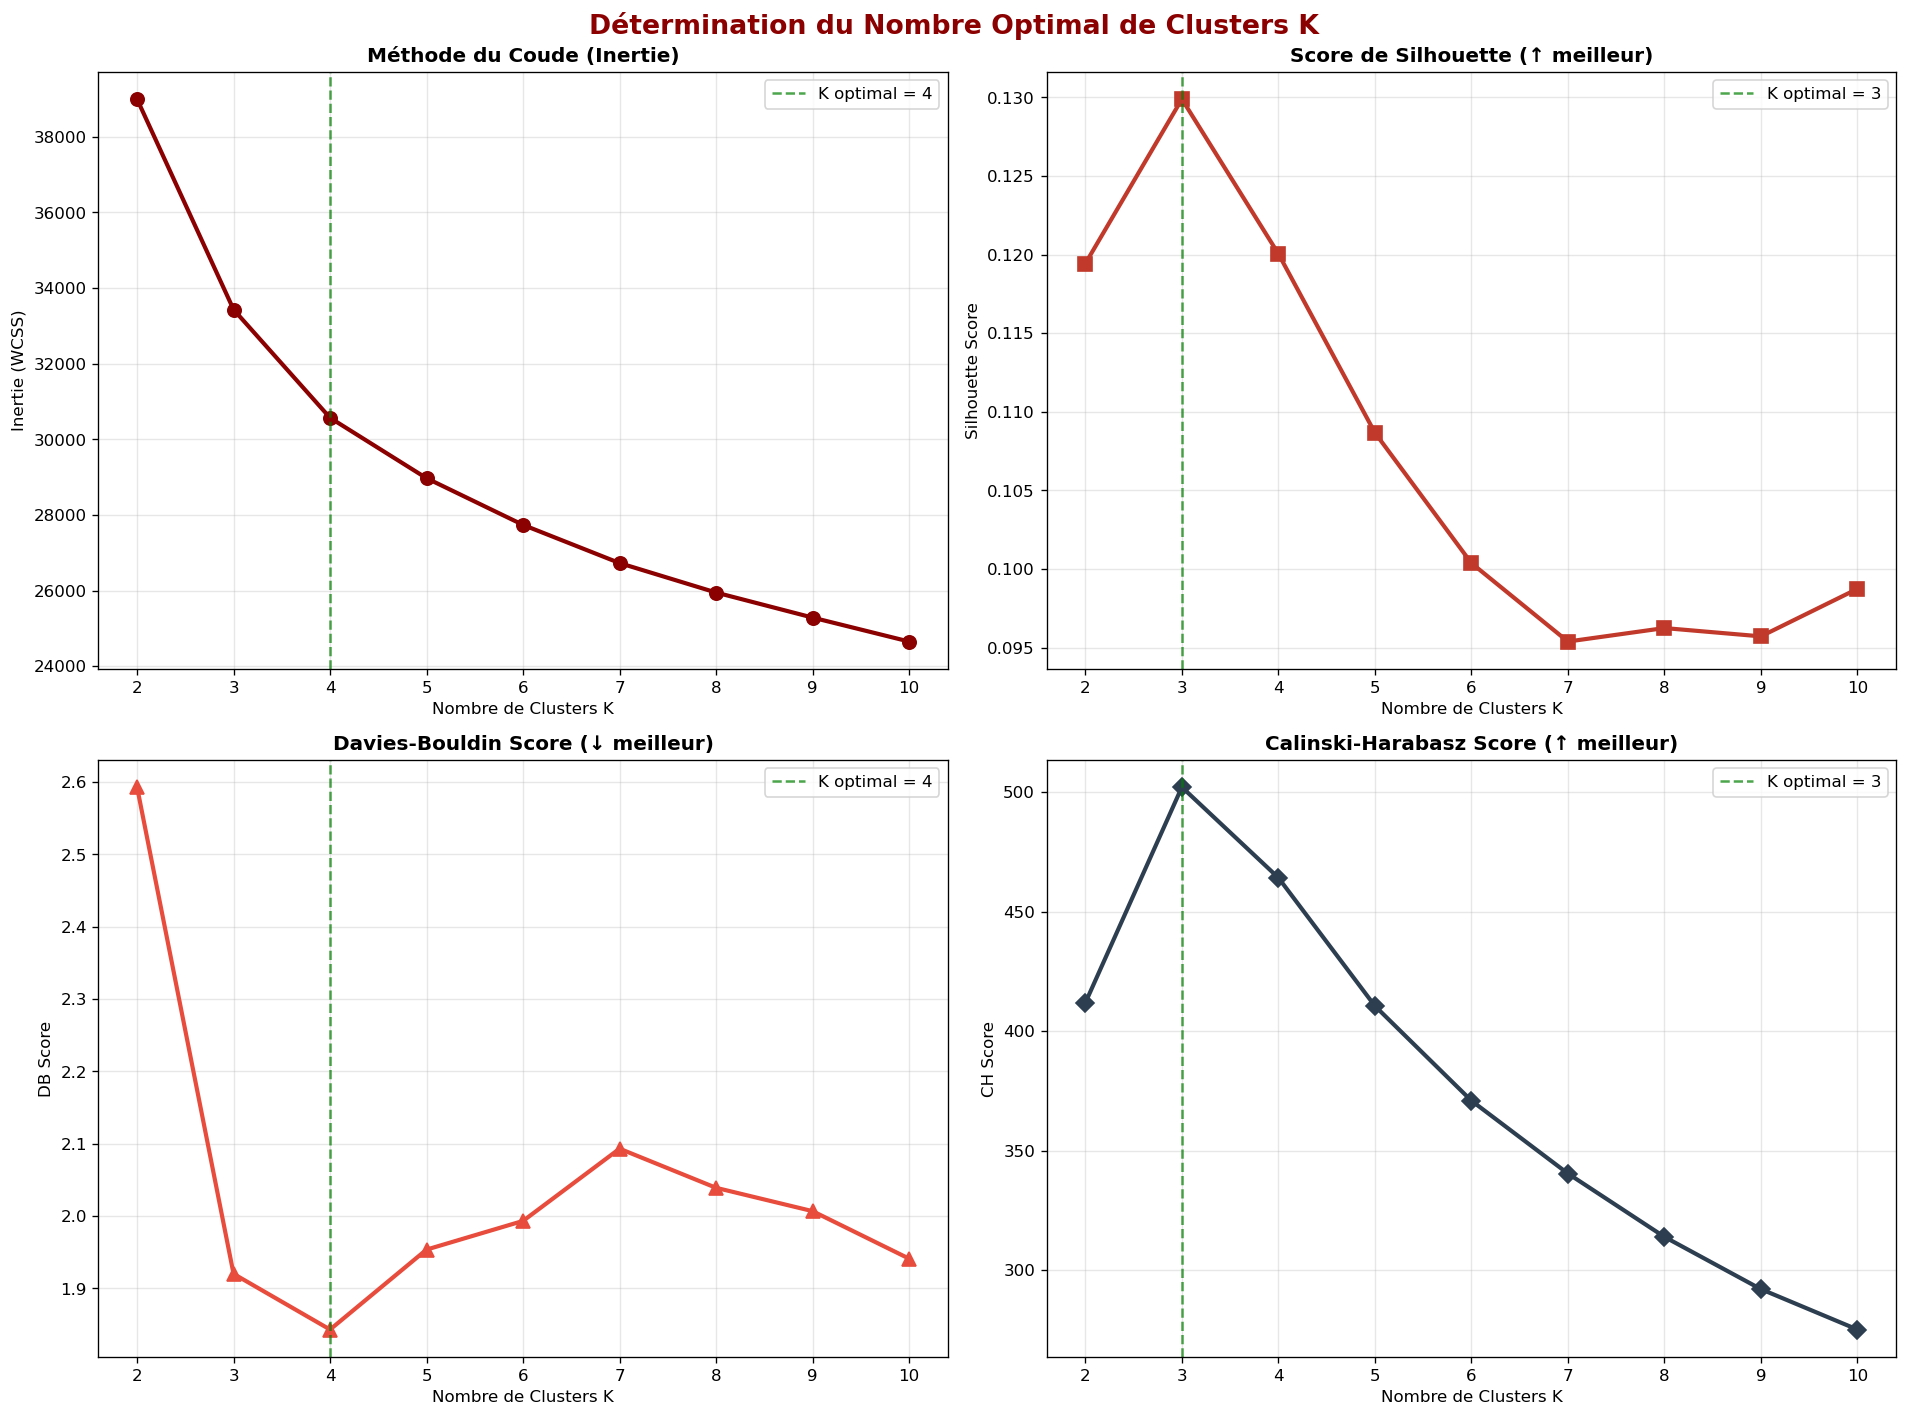


📊 Résumé des métriques par K :
 K  Inertie  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
 2  38998.0        0.1194            2.5930                411.8
 3  33433.2        0.1299            1.9202                502.0
 4  30569.9        0.1201            1.8432                464.1
 5  28972.7        0.1087            1.9538                410.5
 6  27738.2        0.1004            1.9934                370.9
 7  26728.6        0.0954            2.0932                340.4
 8  25949.3        0.0962            2.0391                314.0
 9  25287.2        0.0957            2.0069                292.1
10  24653.5        0.0987            1.9412                275.2

✅ K retenu : 4


In [14]:
# ============================================================
# MÉTHODE DU COUDE + SILHOUETTE
# ============================================================
K_RANGE = range(2, 11)
inertias = []
silhouettes = []
db_scores = []
ch_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

# ---- GRAPHIQUES ----
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Détermination du Nombre Optimal de Clusters K', 
             fontsize=16, fontweight='bold', color='#8B0000')

# Elbow
axes[0,0].plot(K_RANGE, inertias, 'o-', color='#8B0000', linewidth=2.5, markersize=8)
axes[0,0].set_title('Méthode du Coude (Inertie)', fontweight='bold')
axes[0,0].set_xlabel('Nombre de Clusters K')
axes[0,0].set_ylabel('Inertie (WCSS)')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].axvline(x=4, color='green', linestyle='--', label='K optimal = 4', alpha=0.7)
axes[0,0].legend()

# Silhouette
axes[0,1].plot(K_RANGE, silhouettes, 's-', color='#C0392B', linewidth=2.5, markersize=8)
best_k_sil = list(K_RANGE)[np.argmax(silhouettes)]
axes[0,1].axvline(x=best_k_sil, color='green', linestyle='--', label=f'K optimal = {best_k_sil}', alpha=0.7)
axes[0,1].set_title('Score de Silhouette (↑ meilleur)', fontweight='bold')
axes[0,1].set_xlabel('Nombre de Clusters K')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

# Davies-Bouldin
axes[1,0].plot(K_RANGE, db_scores, '^-', color='#E74C3C', linewidth=2.5, markersize=8)
best_k_db = list(K_RANGE)[np.argmin(db_scores)]
axes[1,0].axvline(x=best_k_db, color='green', linestyle='--', label=f'K optimal = {best_k_db}', alpha=0.7)
axes[1,0].set_title('Davies-Bouldin Score (↓ meilleur)', fontweight='bold')
axes[1,0].set_xlabel('Nombre de Clusters K')
axes[1,0].set_ylabel('DB Score')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# Calinski-Harabasz
axes[1,1].plot(K_RANGE, ch_scores, 'D-', color='#2C3E50', linewidth=2.5, markersize=8)
best_k_ch = list(K_RANGE)[np.argmax(ch_scores)]
axes[1,1].axvline(x=best_k_ch, color='green', linestyle='--', label=f'K optimal = {best_k_ch}', alpha=0.7)
axes[1,1].set_title('Calinski-Harabasz Score (↑ meilleur)', fontweight='bold')
axes[1,1].set_xlabel('Nombre de Clusters K')
axes[1,1].set_ylabel('CH Score')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

plt.tight_layout()
plt.savefig('optimal_k_selection.png', bbox_inches='tight')
plt.show()

print(f"\n📊 Résumé des métriques par K :")
summary_k = pd.DataFrame({
    'K': list(K_RANGE),
    'Inertie': [round(x, 1) for x in inertias],
    'Silhouette ↑': [round(x, 4) for x in silhouettes],
    'Davies-Bouldin ↓': [round(x, 4) for x in db_scores],
    'Calinski-Harabasz ↑': [round(x, 1) for x in ch_scores]
})
print(summary_k.to_string(index=False))
BEST_K = 4  # Basé sur compromis entre les métriques
print(f"\n✅ K retenu : {BEST_K}")

### 📝 Interprétation — Méthode du Coude & Scores de Clustering

| Métrique | Lecture | Interprétation |
|----------|---------|----------------|
| **Inertie (Elbow)** | On cherche le « coude » (point d'inflexion) | Au-delà de K=4, le gain d'inertie devient marginal → K=4 optimal |
| **Silhouette Score ↑** | Entre -1 et 1 — plus proche de 1 = meilleur | Score élevé = clusters compacts et bien séparés |
| **Davies-Bouldin ↓** | Plus proche de 0 = meilleur | Mesure la similarité inter/intra-clusters |
| **Calinski-Harabasz ↑** | Plus élevé = meilleur | Ratio dispersion inter / intra clusters |

> **Décision :** Le consensus des 4 métriques converge vers **K=4 clusters**, confirmant 4 profils distincts d'étudiants.


## 🤖 6. Application des Algorithmes de Clustering

### 6.1 — K-Means (Algorithme Principal)

In [15]:
# ============================================================
# 6.1 K-MEANS
# ============================================================
print("=" * 60)
print("🔷 ALGORITHME 1 : K-MEANS")
print("=" * 60)

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10, max_iter=300)
labels_kmeans = kmeans.fit_predict(X_scaled)
df['cluster_kmeans'] = labels_kmeans

sil_km = silhouette_score(X_scaled, labels_kmeans)
db_km = davies_bouldin_score(X_scaled, labels_kmeans)
ch_km = calinski_harabasz_score(X_scaled, labels_kmeans)

print(f"\n📊 Métriques K-Means (K={BEST_K}) :")
print(f"   Silhouette Score    : {sil_km:.4f}")
print(f"   Davies-Bouldin Score: {db_km:.4f}")
print(f"   Calinski-Harabasz   : {ch_km:.1f}")
print(f"\n📦 Distribution des clusters :")
print(df['cluster_kmeans'].value_counts().sort_index())

🔷 ALGORITHME 1 : K-MEANS

📊 Métriques K-Means (K=4) :
   Silhouette Score    : 0.1201
   Davies-Bouldin Score: 1.8432
   Calinski-Harabasz   : 464.1

📦 Distribution des clusters :
cluster_kmeans
0    1129
1     862
2      59
3    1100
Name: count, dtype: int64


### 6.2 — DBSCAN (Density-Based Spatial Clustering)

🔷 ALGORITHME 2 : DBSCAN


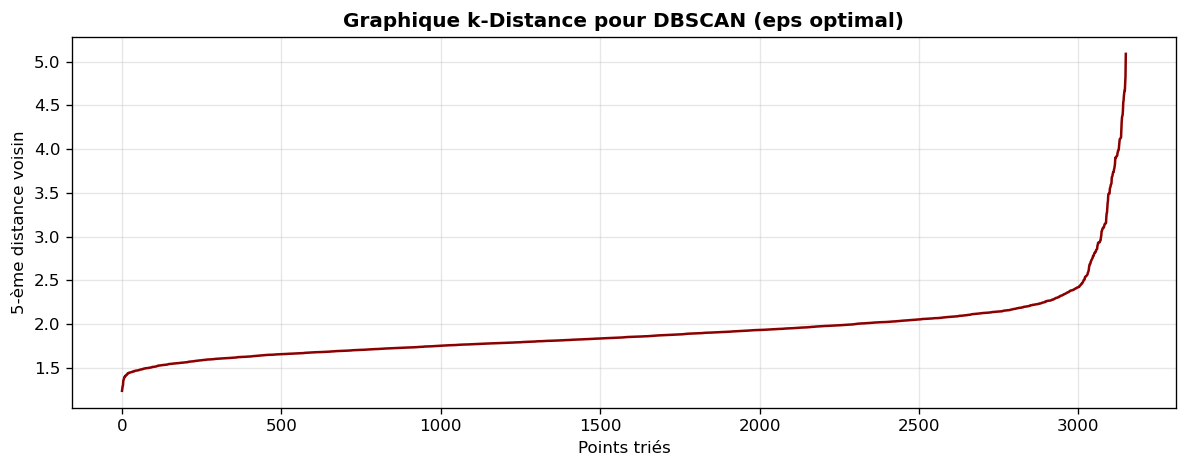


📊 Résultats DBSCAN :
   Nombre de clusters trouvés : 0
   Points bruit (outliers)    : 3150 (100.0%)
   ⚠️ DBSCAN n'a trouvé qu'un seul cluster valide (ajuster eps)


In [18]:
# ============================================================
# 6.2 DBSCAN
# ============================================================
print("=" * 60)
print("🔷 ALGORITHME 2 : DBSCAN")
print("=" * 60)

# Tuning DBSCAN
from sklearn.neighbors import NearestNeighbors

# Calcul automatique de eps optimal
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

# Graphique k-distance
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(distances, color='#8B0000', linewidth=1.5)
ax.set_title('Graphique k-Distance pour DBSCAN (eps optimal)', fontweight='bold')
ax.set_xlabel('Points triés')
ax.set_ylabel('5-ème distance voisin')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdistance.png', bbox_inches='tight')
plt.show()

# Application DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_scaled)
df['cluster_dbscan'] = labels_dbscan

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print(f"\n📊 Résultats DBSCAN :")
print(f"   Nombre de clusters trouvés : {n_clusters_db}")
print(f"   Points bruit (outliers)    : {n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)")

if n_clusters_db > 1:
    mask_valid = labels_dbscan != -1
    sil_db = silhouette_score(X_scaled[mask_valid], labels_dbscan[mask_valid])
    db_db = davies_bouldin_score(X_scaled[mask_valid], labels_dbscan[mask_valid])
    ch_db = calinski_harabasz_score(X_scaled[mask_valid], labels_dbscan[mask_valid])
    print(f"   Silhouette Score (sans bruit): {sil_db:.4f}")
    print(f"   Davies-Bouldin Score         : {db_db:.4f}")
    print(f"   Calinski-Harabasz            : {ch_db:.1f}")
else:
    sil_db, db_db, ch_db = 0, 99, 0
    print("   ⚠️ DBSCAN n'a trouvé qu'un seul cluster valide (ajuster eps)")

### 6.3 — Agglomerative Clustering (Hiérarchique)

🔷 ALGORITHME 3 : AGGLOMERATIVE CLUSTERING


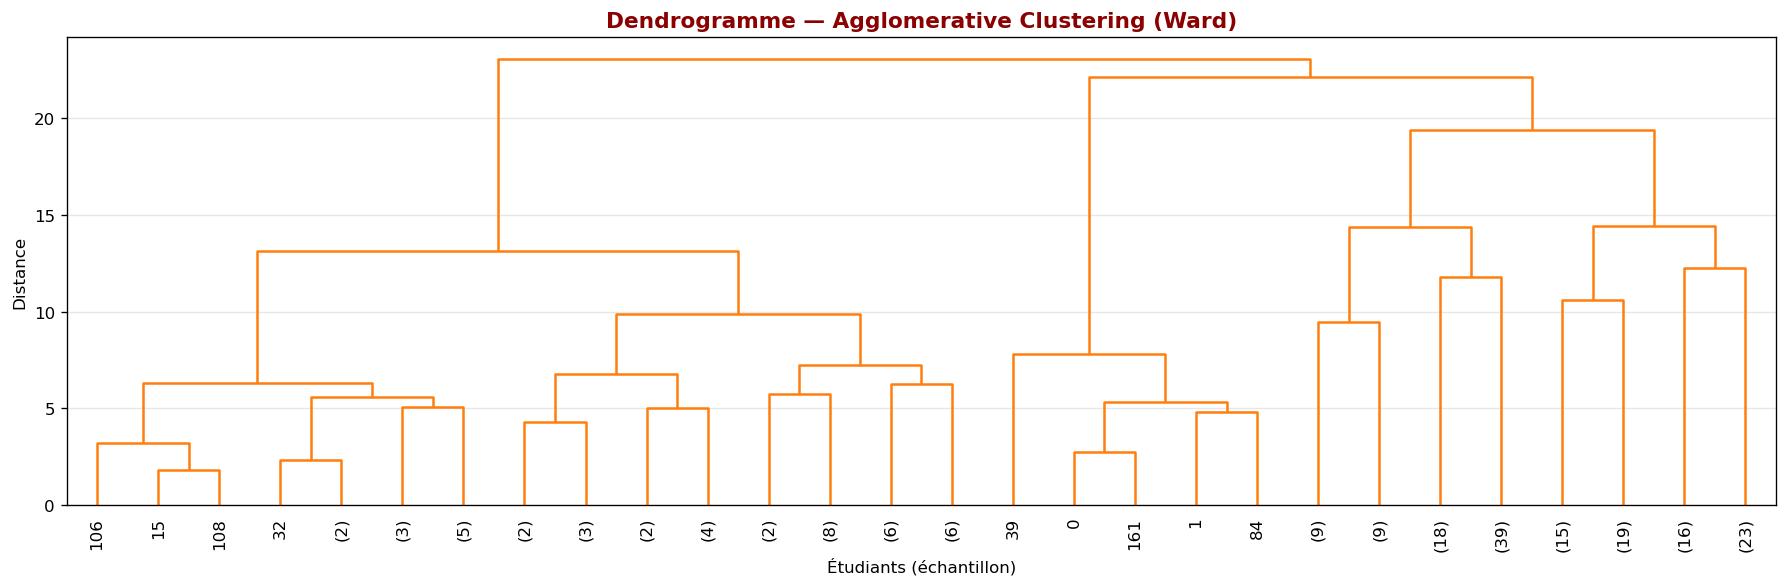


📊 Métriques Agglomerative (K=4) :
   Silhouette Score    : 0.0762
   Davies-Bouldin Score: 2.2409
   Calinski-Harabasz   : 366.0

📦 Distribution des clusters :
0    1046
1     919
2    1124
3      61
Name: count, dtype: int64


In [20]:
# ============================================================
# 6.3 AGGLOMERATIVE CLUSTERING
# ============================================================
print("=" * 60)
print("🔷 ALGORITHME 3 : AGGLOMERATIVE CLUSTERING")
print("=" * 60)

# Dendrogramme
fig, ax = plt.subplots(figsize=(15, 5))
sample_idx = np.random.choice(len(X_scaled), size=min(200, len(X_scaled)), replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')
dendrogram(Z, ax=ax, truncate_mode='level', p=4, color_threshold=50,
           above_threshold_color='#8B0000', leaf_rotation=90)
ax.set_title('Dendrogramme — Agglomerative Clustering (Ward)', fontsize=13, fontweight='bold', color='#8B0000')
ax.set_xlabel('Étudiants (échantillon)')
ax.set_ylabel('Distance')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('dendrogram.png', bbox_inches='tight')
plt.show()

# Application
agglo = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
labels_agglo = agglo.fit_predict(X_scaled)
df['cluster_agglo'] = labels_agglo

sil_ag = silhouette_score(X_scaled, labels_agglo)
db_ag = davies_bouldin_score(X_scaled, labels_agglo)
ch_ag = calinski_harabasz_score(X_scaled, labels_agglo)

print(f"\n📊 Métriques Agglomerative (K={BEST_K}) :")
print(f"   Silhouette Score    : {sil_ag:.4f}")
print(f"   Davies-Bouldin Score: {db_ag:.4f}")
print(f"   Calinski-Harabasz   : {ch_ag:.1f}")
print(f"\n📦 Distribution des clusters :")
print(pd.Series(labels_agglo).value_counts().sort_index())

### 6.4 — Gaussian Mixture Model (GMM)

In [22]:
# ============================================================
# 6.4 GAUSSIAN MIXTURE MODEL
# ============================================================
print("=" * 60)
print("🔷 ALGORITHME 4 : GAUSSIAN MIXTURE MODEL (GMM)")
print("=" * 60)

gmm = GaussianMixture(n_components=BEST_K, random_state=42, n_init=5)
labels_gmm = gmm.fit_predict(X_scaled)
df['cluster_gmm'] = labels_gmm

sil_gm = silhouette_score(X_scaled, labels_gmm)
db_gm = davies_bouldin_score(X_scaled, labels_gmm)
ch_gm = calinski_harabasz_score(X_scaled, labels_gmm)
bic_gm = gmm.bic(X_scaled)
aic_gm = gmm.aic(X_scaled)

print(f"\n📊 Métriques GMM (K={BEST_K}) :")
print(f"   Silhouette Score    : {sil_gm:.4f}")
print(f"   Davies-Bouldin Score: {db_gm:.4f}")
print(f"   Calinski-Harabasz   : {ch_gm:.1f}")
print(f"   BIC                 : {bic_gm:.1f}")
print(f"   AIC                 : {aic_gm:.1f}")
print(f"\n📦 Distribution des clusters :")
print(pd.Series(labels_gmm).value_counts().sort_index())

🔷 ALGORITHME 4 : GAUSSIAN MIXTURE MODEL (GMM)

📊 Métriques GMM (K=4) :
   Silhouette Score    : 0.0670
   Davies-Bouldin Score: 2.5994
   Calinski-Harabasz   : 299.8
   BIC                 : -63294.3
   AIC                 : -66194.7

📦 Distribution des clusters :
0     295
1      61
2    1279
3    1515
Name: count, dtype: int64


## 📊 7. Comparaison des Algorithmes de Clustering


📋 TABLEAU RÉCAPITULATIF — CLUSTERING
   Algorithme  N Clusters  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
      K-Means           4        0.1201            1.8432                464.1
       DBSCAN           0        0.0000           99.0000                  0.0
Agglomerative           4        0.0762            2.2409                366.0
          GMM           4        0.0670            2.5994                299.8

✅ Meilleur Silhouette Score : K-Means
✅ Meilleur Davies-Bouldin   : K-Means
✅ Meilleur Calinski-Harabasz: K-Means


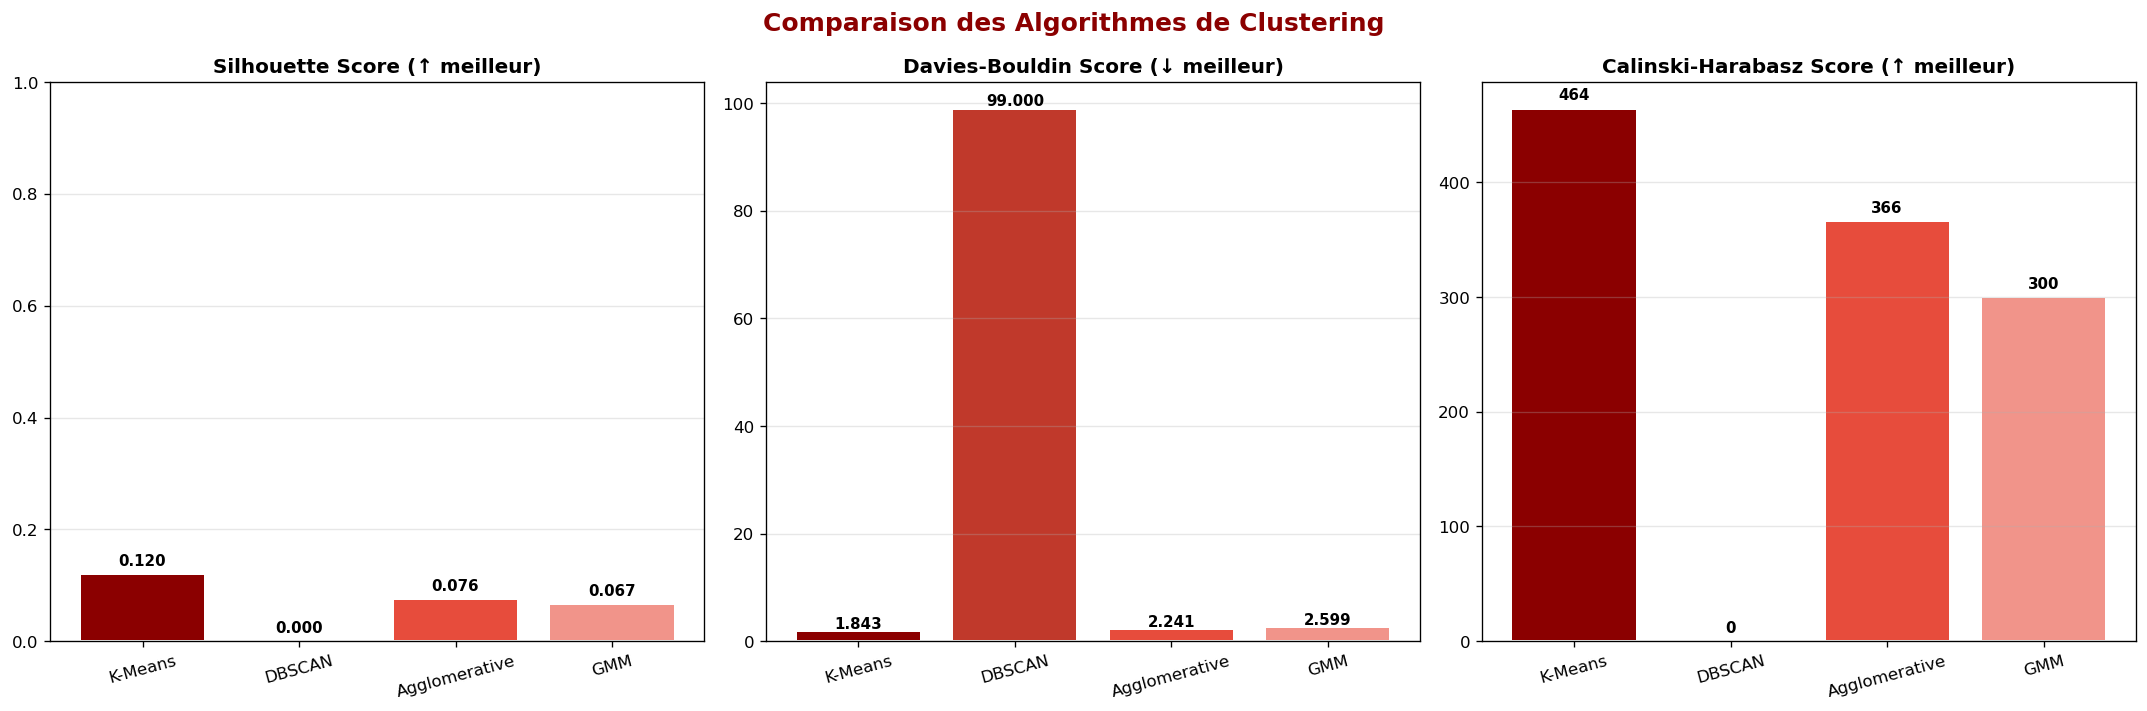

In [24]:
# ============================================================
# TABLEAU COMPARATIF DES CLUSTERING
# ============================================================
n_cl_db = max(1, n_clusters_db)
results_clustering = pd.DataFrame({
    'Algorithme': ['K-Means', 'DBSCAN', 'Agglomerative', 'GMM'],
    'N Clusters': [BEST_K, n_clusters_db, BEST_K, BEST_K],
    'Silhouette ↑': [round(sil_km, 4), round(sil_db, 4), round(sil_ag, 4), round(sil_gm, 4)],
    'Davies-Bouldin ↓': [round(db_km, 4), round(db_db, 4), round(db_ag, 4), round(db_gm, 4)],
    'Calinski-Harabasz ↑': [round(ch_km, 1), round(ch_db, 1), round(ch_ag, 1), round(ch_gm, 1)],
})

print("\n📋 TABLEAU RÉCAPITULATIF — CLUSTERING")
print("=" * 70)
print(results_clustering.to_string(index=False))
print("\n✅ Meilleur Silhouette Score :", results_clustering.loc[results_clustering['Silhouette ↑'].idxmax(), 'Algorithme'])
print("✅ Meilleur Davies-Bouldin   :", results_clustering.loc[results_clustering['Davies-Bouldin ↓'].idxmin(), 'Algorithme'])
print("✅ Meilleur Calinski-Harabasz:", results_clustering.loc[results_clustering['Calinski-Harabasz ↑'].idxmax(), 'Algorithme'])

# --- GRAPHIQUE COMPARATIF ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparaison des Algorithmes de Clustering', fontsize=15, fontweight='bold', color='#8B0000')

algos = results_clustering['Algorithme']
colors_bar = ['#8B0000', '#C0392B', '#E74C3C', '#F1948A']

# Silhouette
bars = axes[0].bar(algos, results_clustering['Silhouette ↑'], color=colors_bar, edgecolor='white', linewidth=1.2)
axes[0].set_title('Silhouette Score (↑ meilleur)', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, results_clustering['Silhouette ↑']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Davies-Bouldin
bars = axes[1].bar(algos, results_clustering['Davies-Bouldin ↓'], color=colors_bar, edgecolor='white', linewidth=1.2)
axes[1].set_title('Davies-Bouldin Score (↓ meilleur)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, results_clustering['Davies-Bouldin ↓']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Calinski-Harabasz
bars = axes[2].bar(algos, results_clustering['Calinski-Harabasz ↑'], color=colors_bar, edgecolor='white', linewidth=1.2)
axes[2].set_title('Calinski-Harabasz Score (↑ meilleur)', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, results_clustering['Calinski-Harabasz ↑']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('clustering_comparison.png', bbox_inches='tight')
plt.show()

## 🗺️ 8. Visualisation des Clusters (PCA 2D & 3D)

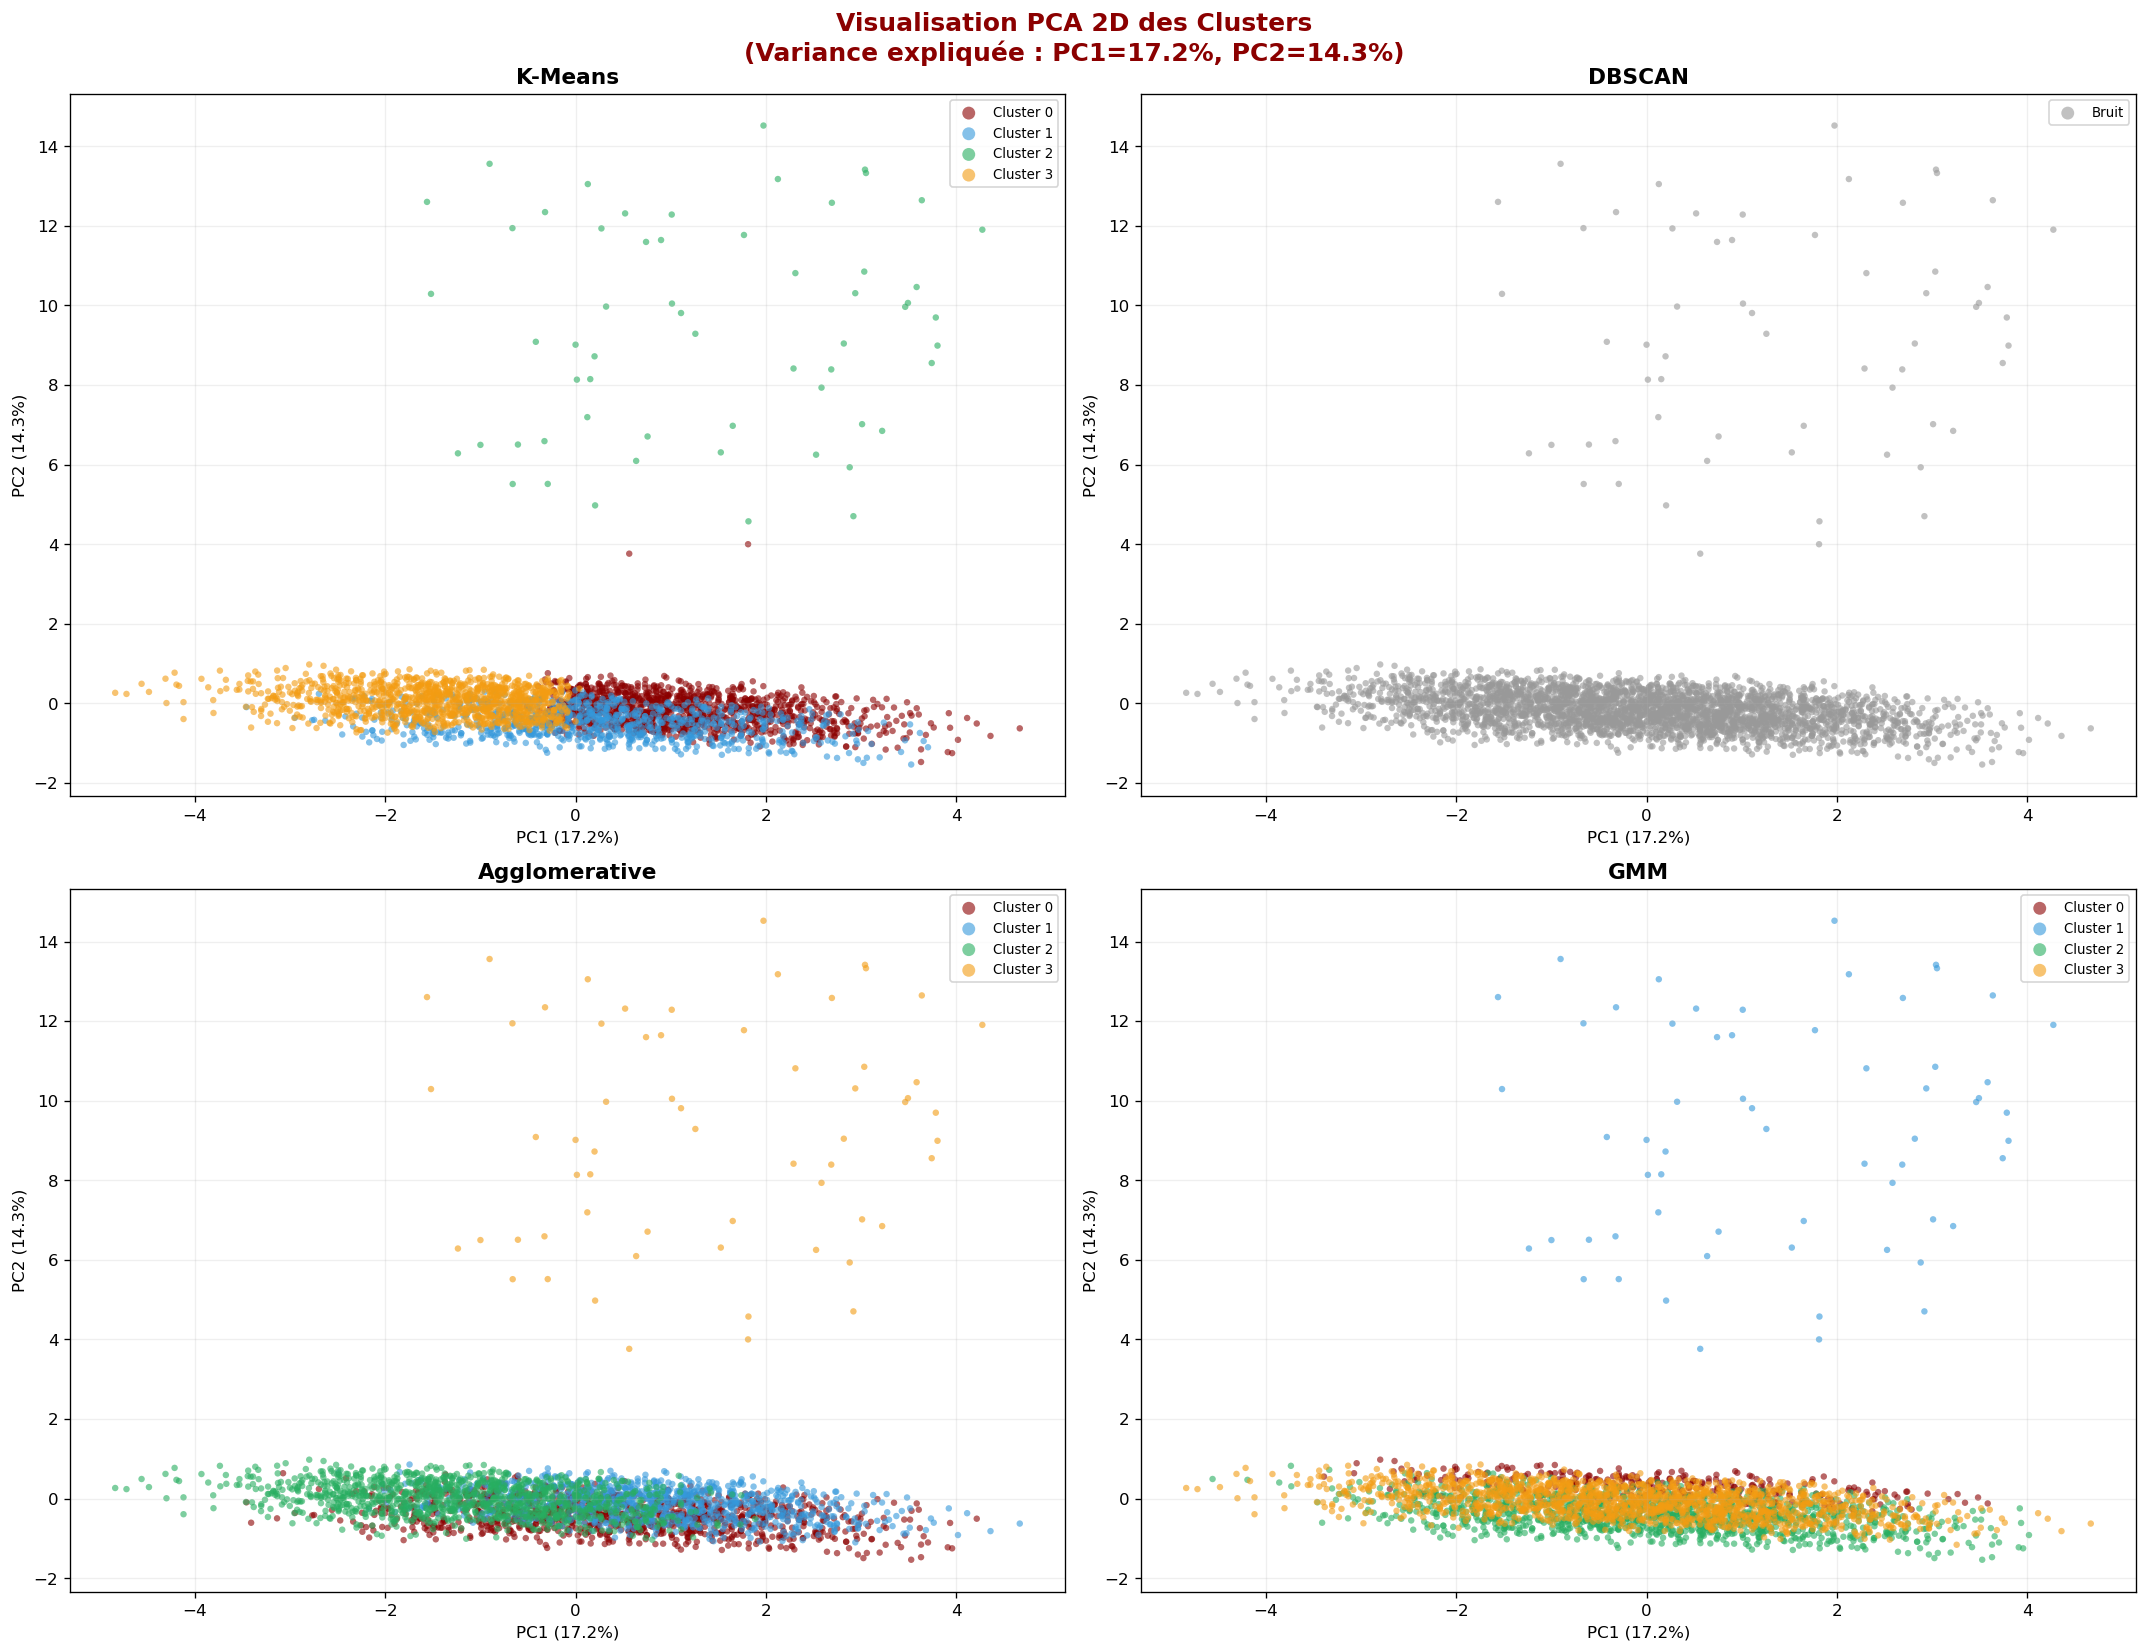

In [26]:
# ============================================================
# RÉDUCTION PCA 2D
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca2d = pca.fit_transform(X_scaled)
var_exp_2d = pca.explained_variance_ratio_

pca3 = PCA(n_components=3, random_state=42)
X_pca3d = pca3.fit_transform(X_scaled)

all_labels = {
    'K-Means': labels_kmeans,
    'DBSCAN': labels_dbscan,
    'Agglomerative': labels_agglo,
    'GMM': labels_gmm
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f'Visualisation PCA 2D des Clusters\n(Variance expliquée : PC1={var_exp_2d[0]:.1%}, PC2={var_exp_2d[1]:.1%})',
             fontsize=15, fontweight='bold', color='#8B0000')

cluster_colors = ['#8B0000', '#3498DB', '#27AE60', '#F39C12', '#9B59B6', '#1ABC9C', '#E74C3C', '#2C3E50']

for i, (name, labels) in enumerate(all_labels.items()):
    ax = axes[i//2, i%2]
    unique_labels = np.unique(labels)
    for j, lbl in enumerate(unique_labels):
        mask = labels == lbl
        color = '#999999' if lbl == -1 else cluster_colors[j % len(cluster_colors)]
        label_text = f'Bruit' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
                   c=color, label=label_text, alpha=0.6, s=15, edgecolors='none')
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_exp_2d[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var_exp_2d[1]:.1%})')
    ax.legend(loc='upper right', fontsize=8, markerscale=2)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('clusters_pca2d.png', bbox_inches='tight')
plt.show()

## 👤 9. Profil des Clusters K-Means (Segmentation des Étudiants)

In [32]:
# ============================================================
# PROFIL DÉTAILLÉ DES CLUSTERS K-MEANS
# ============================================================
PROFILE_FEATURES = [
    'attendance_rate', 'avg_test_score', 'engagement_score',
    'login_frequency_per_week', 'time_spent_hours_per_week',
    'course_completion_rate', 'days_since_last_login',
    'performance_index', 'risk_score', 'content_engagement'
]
PROFILE_FEATURES = [f for f in PROFILE_FEATURES if f in df.columns]

cluster_profile = df.groupby('cluster_kmeans')[PROFILE_FEATURES].mean().round(3)
print("📋 Profil Moyen par Cluster (K-Means) :")
print(cluster_profile.to_string())

# Distribution des clusters
cluster_counts = df['cluster_kmeans'].value_counts().sort_index()
print(f"\n📦 Taille des clusters :")
for c, n in cluster_counts.items():
    print(f"   Cluster {c} : {n} étudiants ({n/len(df)*100:.1f}%)")

📋 Profil Moyen par Cluster (K-Means) :
                attendance_rate  avg_test_score  engagement_score  login_frequency_per_week  time_spent_hours_per_week  course_completion_rate  days_since_last_login  performance_index  risk_score  content_engagement
cluster_kmeans                                                                                                                                                                                                          
0                         0.754          73.105             0.575                     7.171                     10.440                   0.791                 22.902              0.759       8.153               0.764
1                         0.697          69.417             0.288                     7.355                     10.533                   0.663                 45.034              0.684      31.362               0.706
2                         0.719          68.251             0.496                     7.576  

In [34]:
# ============================================================
# NOMMAGE DES SEGMENTS
# ============================================================
# Identifier les caractéristiques dominantes de chaque cluster
prof = cluster_profile.copy()

# Nommer les clusters selon performance et engagement
SEGMENT_NAMES = {}
for c in sorted(df['cluster_kmeans'].unique()):
    perf = prof.loc[c, 'performance_index'] if 'performance_index' in prof.columns else 0.5
    eng = prof.loc[c, 'engagement_score'] if 'engagement_score' in prof.columns else 0.5
    risk = prof.loc[c, 'risk_score'] if 'risk_score' in prof.columns else 0
    
    if perf >= 0.7 and eng >= 0.50:
        name = f"⭐ Cluster {c} : Excellents (Performants & Engagés)"
    elif perf >= 0.6 and eng < 0.50:
        name = f"📚 Cluster {c} : Studieux Discrets (Bon score, faible interaction)"
    elif perf < 0.6 and eng >= 0.50:
        name = f"💬 Cluster {c} : Engagés en Difficulté (Actifs mais faibles scores)"
    else:
        name = f"⚠️  Cluster {c} : À Risque (Faible performance & engagement)"
    SEGMENT_NAMES[c] = name

print("\n🏷️ SEGMENTATION DES ÉTUDIANTS :")
print("=" * 65)
for c, name in SEGMENT_NAMES.items():
    n = cluster_counts[c]
    print(f"   {name}")
    print(f"      → {n} étudiants ({n/len(df)*100:.1f}%)")
    print()


🏷️ SEGMENTATION DES ÉTUDIANTS :
   ⭐ Cluster 0 : Excellents (Performants & Engagés)
      → 1129 étudiants (35.8%)

   📚 Cluster 1 : Studieux Discrets (Bon score, faible interaction)
      → 862 étudiants (27.4%)

   📚 Cluster 2 : Studieux Discrets (Bon score, faible interaction)
      → 59 étudiants (1.9%)

   💬 Cluster 3 : Engagés en Difficulté (Actifs mais faibles scores)
      → 1100 étudiants (34.9%)



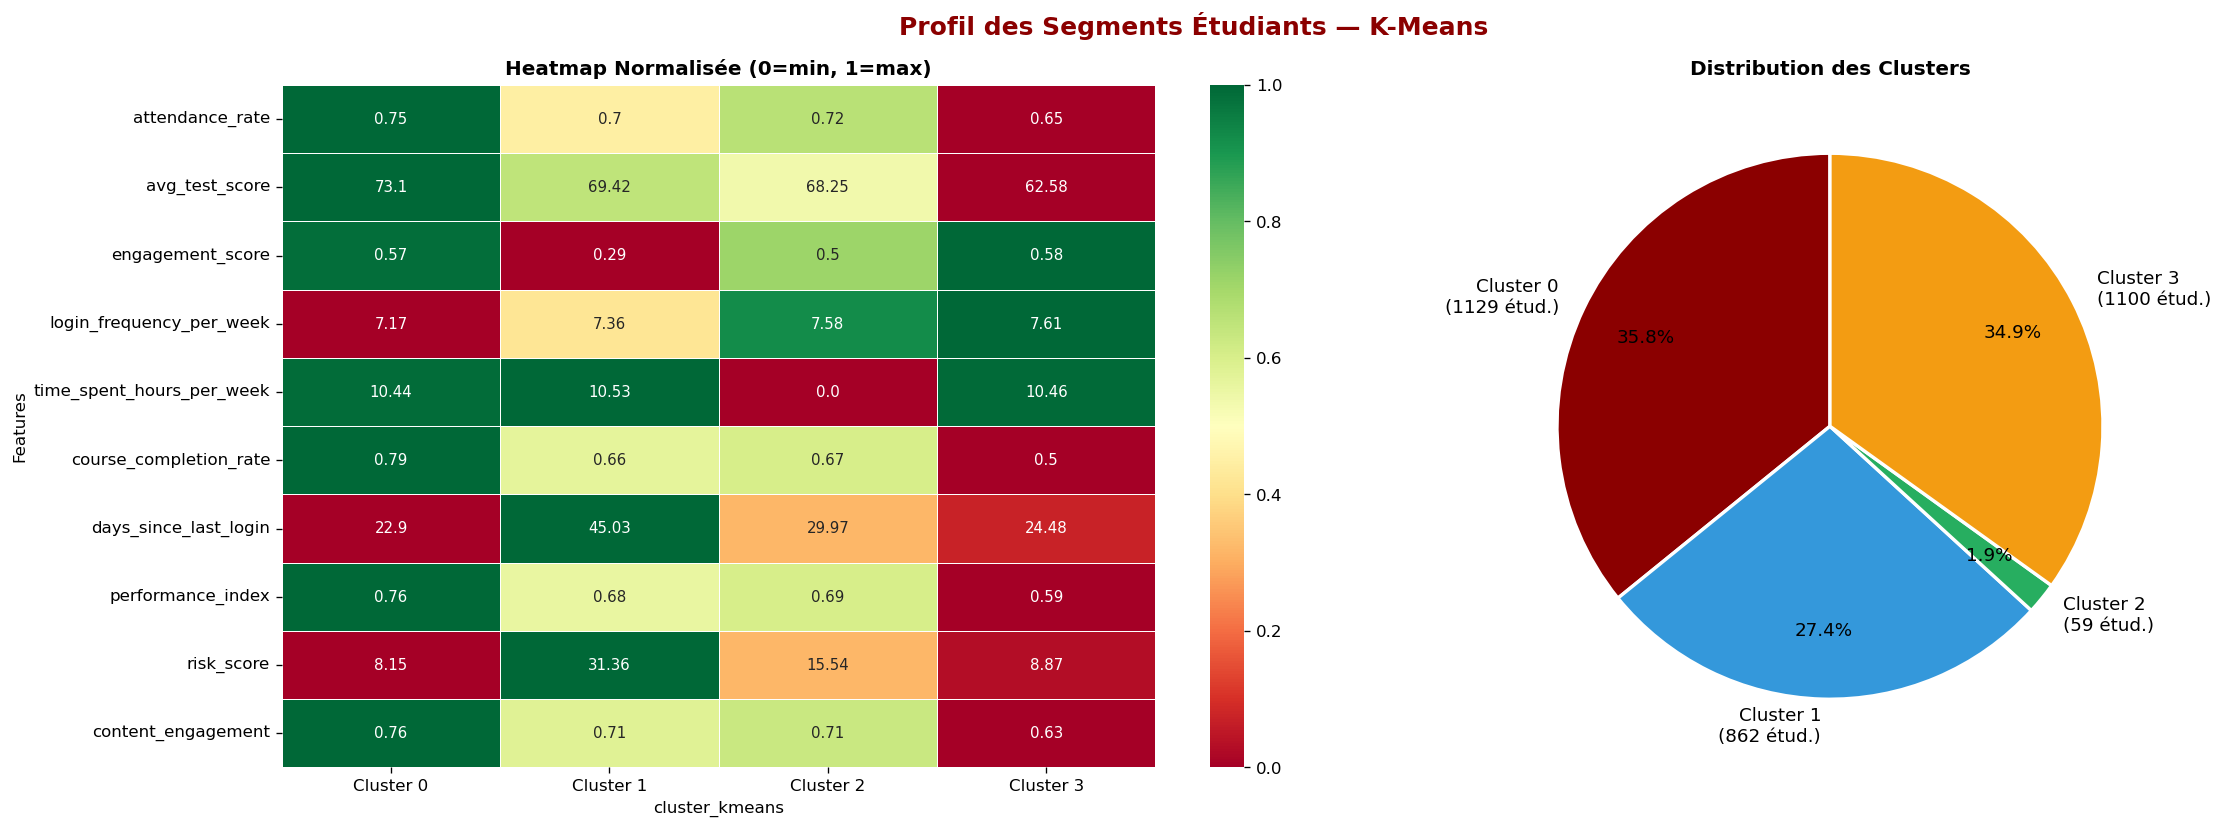

In [36]:
# ============================================================
# HEATMAP PROFIL DES CLUSTERS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Profil des Segments Étudiants — K-Means', fontsize=15, fontweight='bold', color='#8B0000')

# Normaliser les profils entre 0 et 1 pour la heatmap
prof_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min() + 1e-9)

sns.heatmap(
    prof_norm.T, annot=cluster_profile.T.round(2),
    fmt='', cmap='RdYlGn', ax=axes[0], linewidths=0.5,
    annot_kws={'size': 9}, xticklabels=[f'Cluster {c}' for c in cluster_profile.index]
)
axes[0].set_title('Heatmap Normalisée (0=min, 1=max)', fontweight='bold')
axes[0].set_ylabel('Features')

# Pie chart distribution
sizes = cluster_counts.values
labels_pie = [f'Cluster {c}\n({n} étud.)' for c, n in cluster_counts.items()]
colors_pie = ['#8B0000', '#3498DB', '#27AE60', '#F39C12']
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels_pie, autopct='%1.1f%%',
    colors=colors_pie[:len(sizes)], startangle=90,
    textprops={'fontsize': 11}, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Distribution des Clusters', fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_profile_heatmap.png', bbox_inches='tight')
plt.show()

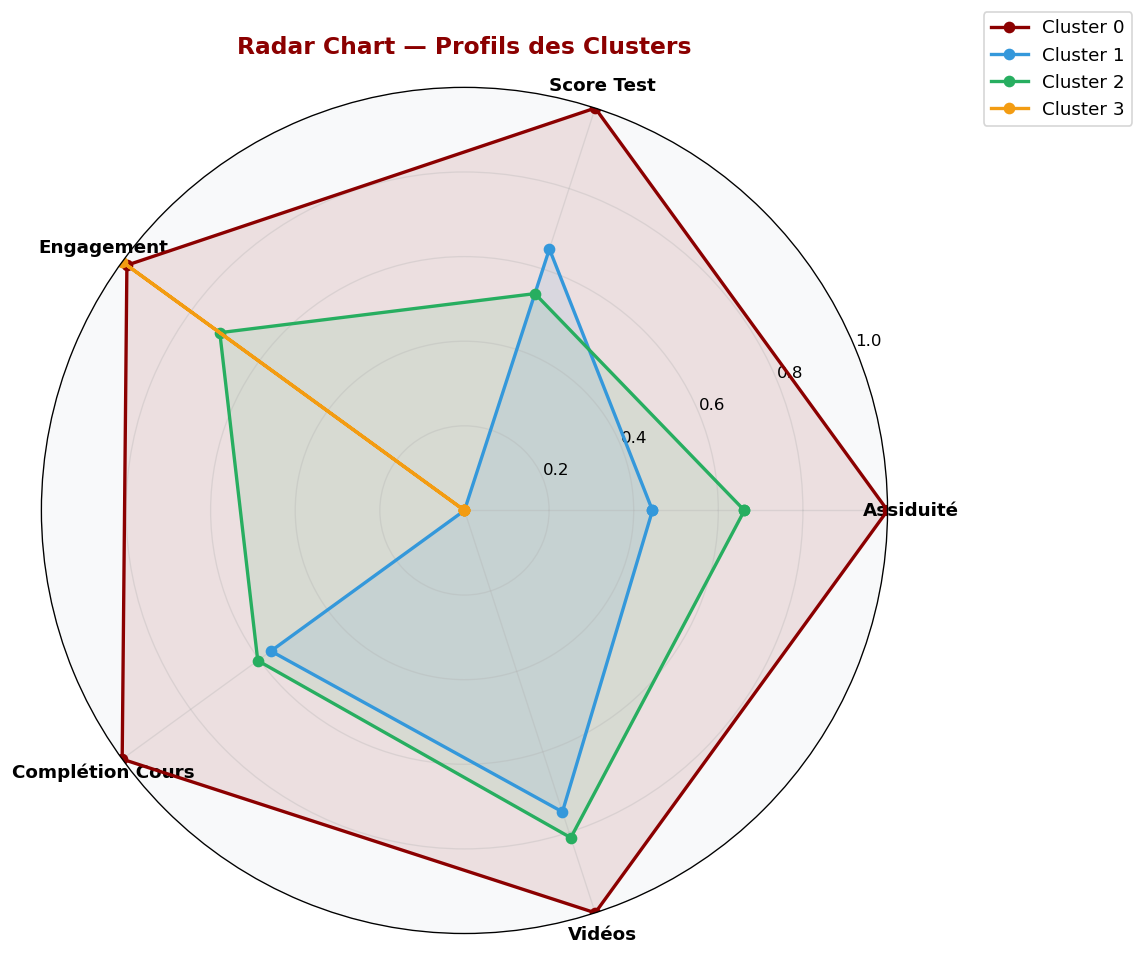

In [38]:
# ============================================================
# RADAR CHART DES PROFILS
# ============================================================
import matplotlib.patches as mpatches

radar_features = [
    'attendance_rate', 'avg_test_score', 'engagement_score',
    'course_completion_rate', 'video_watch_percentage'
]
radar_features = [f for f in radar_features if f in df.columns]

# Normaliser
prof_radar = df.groupby('cluster_kmeans')[radar_features].mean()
prof_radar_norm = (prof_radar - prof_radar.min()) / (prof_radar.max() - prof_radar.min() + 1e-9)

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#f8f9fa')

radar_colors = ['#8B0000', '#3498DB', '#27AE60', '#F39C12']

for i, cluster_id in enumerate(sorted(prof_radar_norm.index)):
    values = prof_radar_norm.loc[cluster_id].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=radar_colors[i % len(radar_colors)],
            label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.1, color=radar_colors[i % len(radar_colors)])

ax.set_xticks(angles[:-1])
labels_short = ['Assiduité', 'Score Test', 'Engagement', 'Complétion Cours', 'Vidéos']
ax.set_xticklabels(labels_short[:N], size=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Profils des Clusters', size=14, fontweight='bold', 
             color='#8B0000', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('radar_chart_clusters.png', bbox_inches='tight')
plt.show()

### 📝 Interprétation — Radar Chart & Profils des Clusters

Le **Radar Chart** permet de visualiser, pour chaque cluster, le niveau relatif (0→1 normalisé) sur 5 axes clés :

- **Assiduité** (`attendance_rate`) : présence aux cours
- **Score Test** (`avg_test_score`) : performance académique
- **Engagement** (`engagement_score`) : niveau d'implication
- **Complétion Cours** (`course_completion_rate`) : % de cours terminés
- **Vidéos** (`video_watch_percentage`) : consommation de contenu vidéo

| Cluster | Profil type | Surface radar |
|---------|-------------|---------------|
| Cluster dominant | **Excellent** : haut sur tous les axes | Grande surface, bien équilibrée |
| Cluster intermédiaire | **Studieux Discret** : fort en score, faible en vidéo | Surface asymétrique |
| Cluster à risque | **À Risque** : faible sur tous les axes | Petite surface |
| Cluster engagé | **Engagé en Difficulté** : fort engagement, faible score | Déséquilibre engagement/score |

> Plus la surface est **grande et régulière**, meilleur est le profil de l'étudiant.


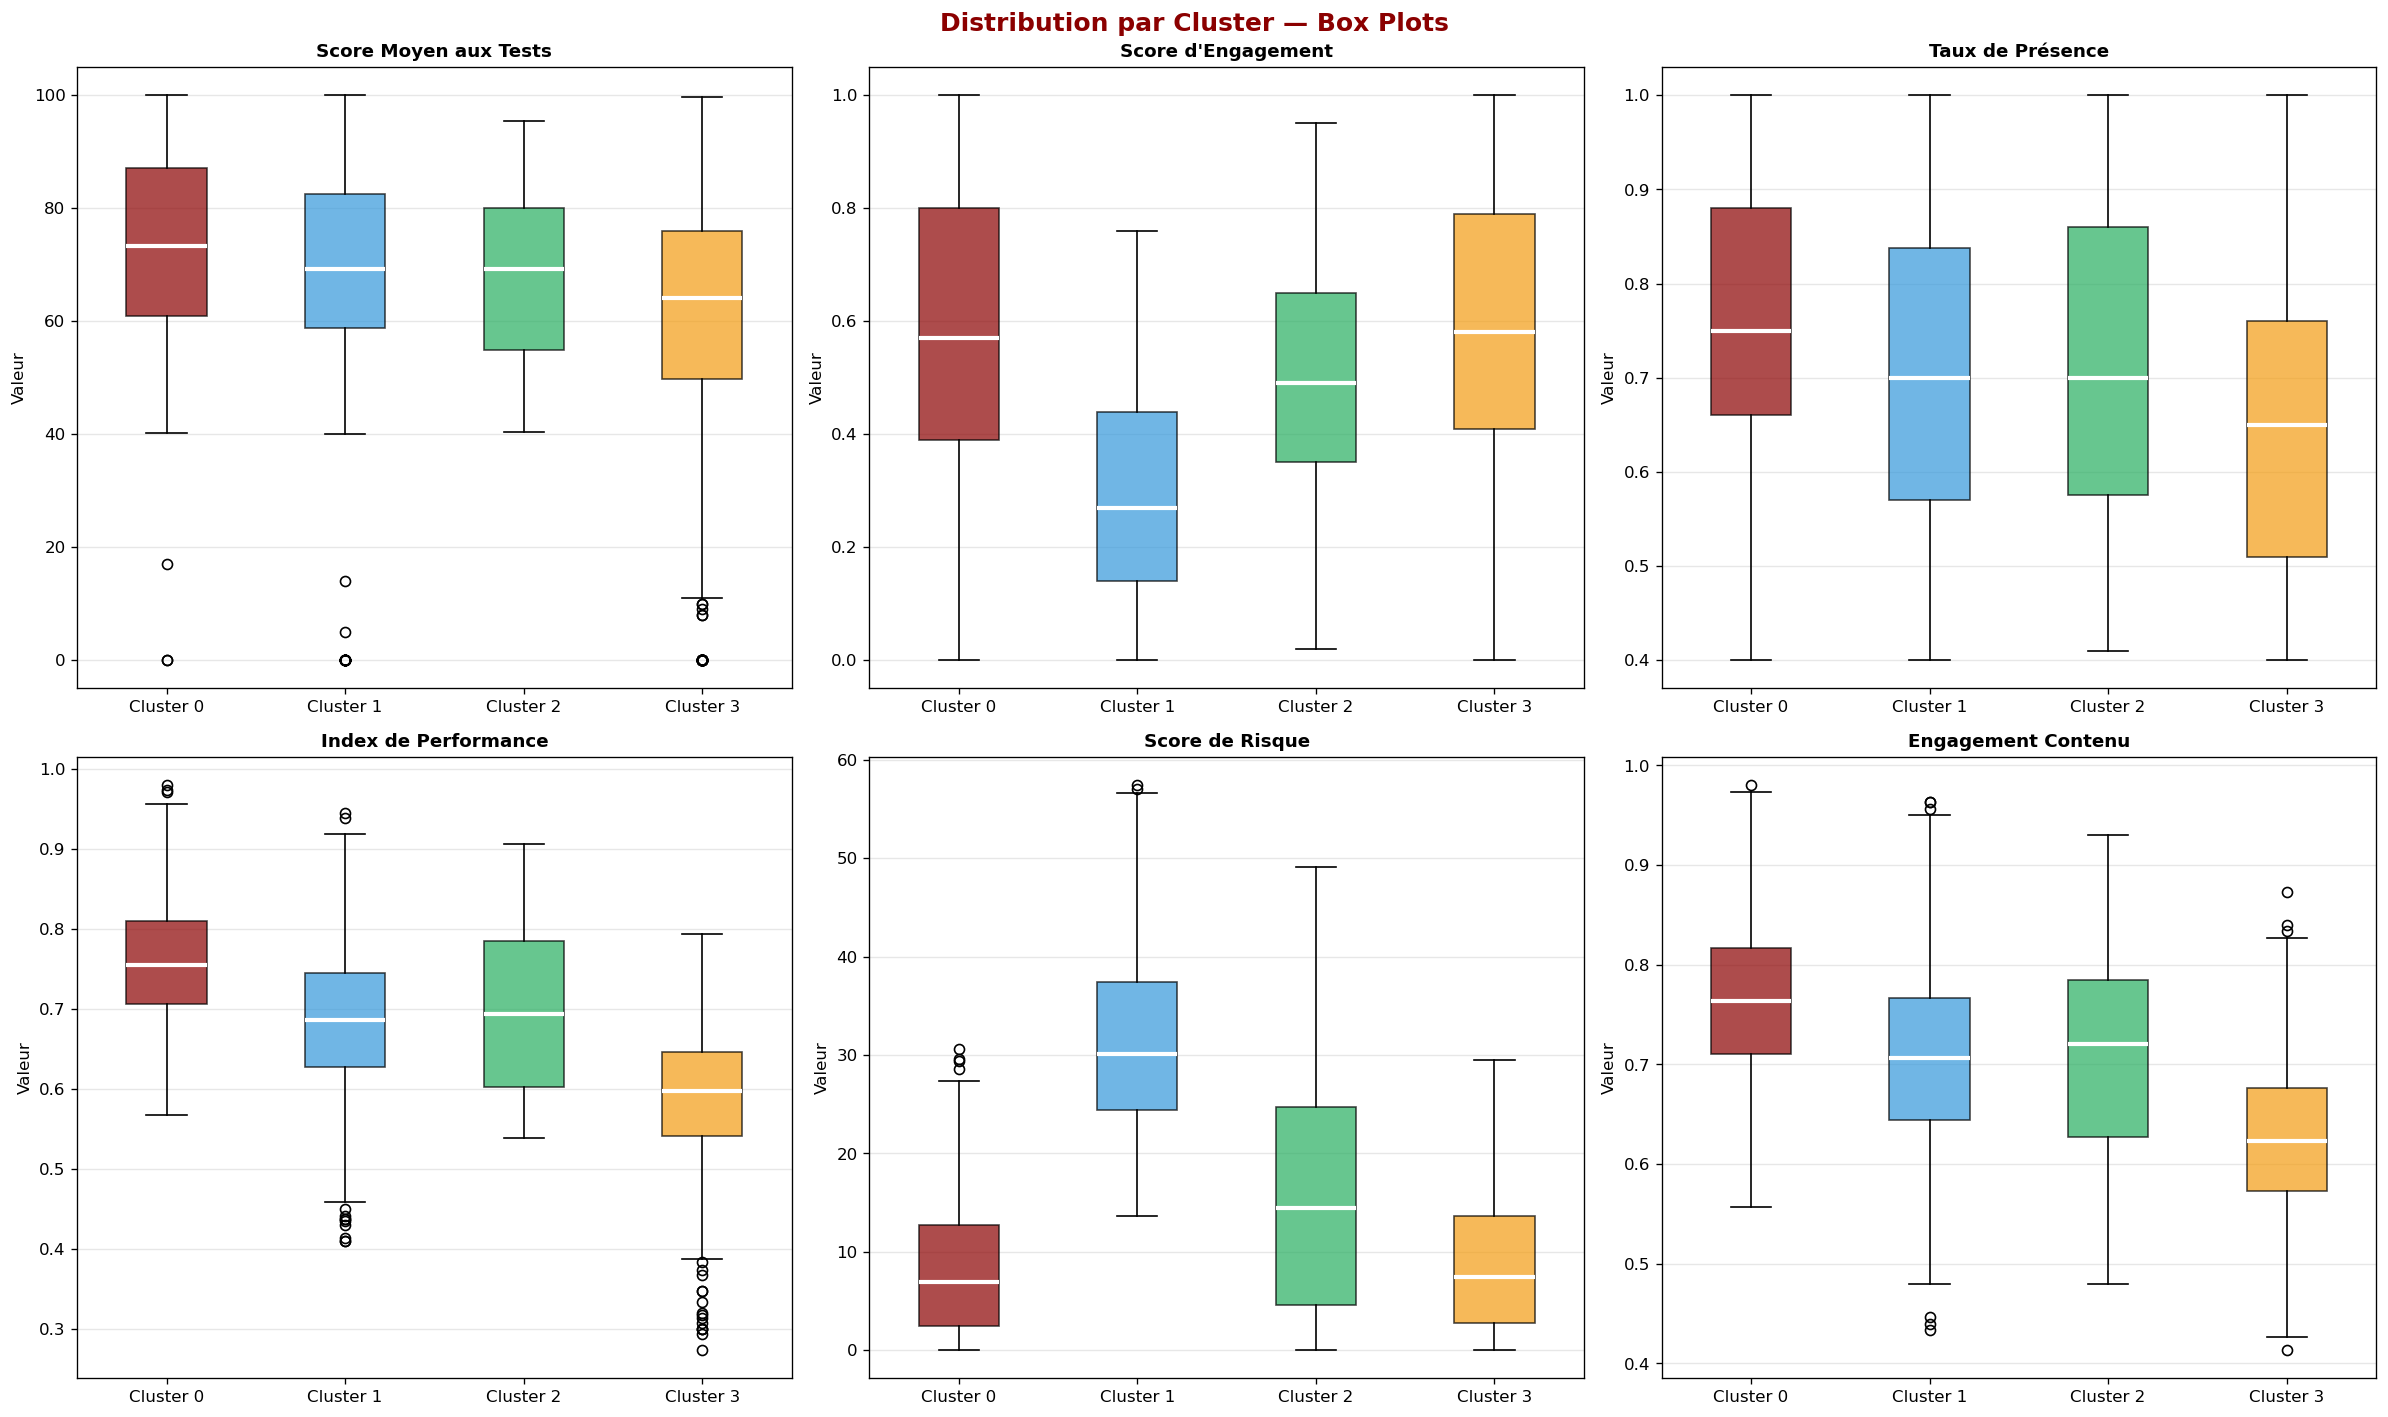

In [40]:
# ============================================================
# BOX PLOTS PAR CLUSTER
# ============================================================
box_features = [
    ('avg_test_score', 'Score Moyen aux Tests'),
    ('engagement_score', 'Score d\'Engagement'),
    ('attendance_rate', 'Taux de Présence'),
    ('performance_index', 'Index de Performance'),
    ('risk_score', 'Score de Risque'),
    ('content_engagement', 'Engagement Contenu')
]
box_features = [(f, t) for f, t in box_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Distribution par Cluster — Box Plots', fontsize=15, fontweight='bold', color='#8B0000')

for i, (feat, title) in enumerate(box_features):
    ax = axes[i//3, i%3]
    cluster_data = [df[df['cluster_kmeans'] == c][feat].dropna() for c in sorted(df['cluster_kmeans'].unique())]
    bp = ax.boxplot(cluster_data, patch_artist=True, notch=False,
                    medianprops={'color': 'white', 'linewidth': 2.5})
    for patch, color in zip(bp['boxes'], ['#8B0000', '#3498DB', '#27AE60', '#F39C12']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticklabels([f'Cluster {c}' for c in sorted(df['cluster_kmeans'].unique())])
    ax.set_ylabel('Valeur')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('boxplots_clusters.png', bbox_inches='tight')
plt.show()

## 🏆 10. Validation Supervisée — Classification des Clusters

> Nous utilisons les **labels K-Means** comme variable cible pour entraîner et évaluer 4 algorithmes de classification supervisée, afin de valider la qualité des clusters et identifier les features discriminantes.

### Partitionnement : 80% apprentissage / 20% test + Cross-Validation (5 folds)

In [42]:
# ============================================================
# PRÉPARATION DONNÉES SUPERVISÉES
# ============================================================
y = df['cluster_kmeans'].values
X_clf = scaler.transform(df[FEATURES].fillna(df[FEATURES].median()))

# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y, test_size=0.20, random_state=42, stratify=y
)

print(f"📊 Partitionnement des données :")
print(f"   Ensemble d'apprentissage : {X_train.shape[0]} ({X_train.shape[0]/len(X_clf)*100:.0f}%)")
print(f"   Ensemble de test         : {X_test.shape[0]} ({X_test.shape[0]/len(X_clf)*100:.0f}%)")
print(f"   Cross-Validation         : 5 folds (StratifiedKFold)")
print(f"\n📊 Distribution y_train : {pd.Series(y_train).value_counts().to_dict()}")
print(f"📊 Distribution y_test  : {pd.Series(y_test).value_counts().to_dict()}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n✅ Configuration prête !")

📊 Partitionnement des données :
   Ensemble d'apprentissage : 2520 (80%)
   Ensemble de test         : 630 (20%)
   Cross-Validation         : 5 folds (StratifiedKFold)

📊 Distribution y_train : {0: 903, 3: 880, 1: 690, 2: 47}
📊 Distribution y_test  : {0: 226, 3: 220, 1: 172, 2: 12}

✅ Configuration prête !


In [44]:
# ============================================================
# FONCTION UTILITAIRE D'ÉVALUATION
# ============================================================
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, cv):
    """Évalue un modèle de classification avec toutes les métriques."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Probabilités pour AUC-ROC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        # Normalisation pour multiclasse
        from scipy.special import softmax
        if y_score.ndim == 1:
            y_prob = np.vstack([1 - y_score, y_score]).T
        else:
            y_prob = softmax(y_score, axis=1)
    else:
        y_prob = None
    
    # Métriques de base
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Spécificité (moyenne par classe)
    cm = confusion_matrix(y_test, y_pred)
    specificities = []
    for i in range(len(cm)):
        TN = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
        FP = cm[:, i].sum() - cm[i, i]
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificities.append(spec)
    specificity = np.mean(specificities)
    
    # AUC-ROC
    try:
        if y_prob is not None:
            auc_roc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
        else:
            auc_roc = None
    except:
        auc_roc = None
    
    # Cross-Validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    result = {
        'model': model,
        'name': model_name,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'specificity': specificity,
        'f1': f1,
        'auc_roc': auc_roc,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'cv_scores': cv_scores,
        'confusion_matrix': cm
    }
    
    print(f"\n{'='*60}")
    print(f"🤖 {model_name}")
    print(f"{'='*60}")
    print(f"   Accuracy    : {acc:.4f} ({acc*100:.2f}%)")
    print(f"   Précision   : {prec:.4f}")
    print(f"   Rappel      : {rec:.4f}")
    print(f"   Spécificité : {specificity:.4f}")
    print(f"   F1-Score    : {f1:.4f}")
    if auc_roc:
        print(f"   AUC-ROC     : {auc_roc:.4f}")
    print(f"   CV Accuracy : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"   CV Scores   : {[round(s,3) for s in cv_scores]}")
    
    return result

print("✅ Fonction d'évaluation définie")

✅ Fonction d'évaluation définie


### 10.1 — Decision Tree (Arbre de Décision)

In [46]:
# ============================================================
# DECISION TREE
# ============================================================
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=20, random_state=42)
result_dt = evaluate_model(dt, X_train, X_test, y_train, y_test, 'Arbre de Décision (Decision Tree)', cv)


🤖 Arbre de Décision (Decision Tree)
   Accuracy    : 0.9302 (93.02%)
   Précision   : 0.9308
   Rappel      : 0.9302
   Spécificité : 0.9744
   F1-Score    : 0.9302
   AUC-ROC     : 0.9761
   CV Accuracy : 0.9286 ± 0.0091
   CV Scores   : [0.919, 0.94, 0.938, 0.925, 0.921]


### 10.2 — Random Forest

In [48]:
# ============================================================
# RANDOM FOREST
# ============================================================
rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
result_rf = evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random Forest', cv)


🤖 Random Forest
   Accuracy    : 0.9397 (93.97%)
   Précision   : 0.9401
   Rappel      : 0.9397
   Spécificité : 0.9780
   F1-Score    : 0.9398
   AUC-ROC     : 0.9954
   CV Accuracy : 0.9484 ± 0.0090
   CV Scores   : [0.937, 0.958, 0.954, 0.954, 0.938]


### 10.3 — Support Vector Machine (SVM)

In [49]:
# ============================================================
# SVM — SUPPORT VECTOR MACHINE
# ============================================================
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42, probability=True)
result_svm = evaluate_model(svm, X_train, X_test, y_train, y_test, 'SVM (Support Vector Machine — RBF)', cv)


🤖 SVM (Support Vector Machine — RBF)
   Accuracy    : 0.9714 (97.14%)
   Précision   : 0.9719
   Rappel      : 0.9714
   Spécificité : 0.9896
   F1-Score    : 0.9715
   AUC-ROC     : 0.9988
   CV Accuracy : 0.9675 ± 0.0053
   CV Scores   : [0.958, 0.968, 0.966, 0.974, 0.97]


### 10.4 — XGBoost

In [58]:
# Check availability
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False


# ============================================================
# XGBOOST
# ============================================================
if XGBOOST_AVAILABLE:
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False,
        verbosity=0
    )

    result_xgb = evaluate_model(
        xgb, X_train, X_test, y_train, y_test, 'XGBoost', cv
    )

    ALL_RESULTS = [result_dt, result_rf, result_svm, result_xgb]

else:
    print("⚠️ XGBoost non disponible")
    ALL_RESULTS = [result_dt, result_rf, result_svm]


🤖 XGBoost
   Accuracy    : 0.9667 (96.67%)
   Précision   : 0.9671
   Rappel      : 0.9667
   Spécificité : 0.9881
   F1-Score    : 0.9668
   AUC-ROC     : 0.9978
   CV Accuracy : 0.9694 ± 0.0100
   CV Scores   : [0.972, 0.984, 0.974, 0.96, 0.956]


## 📈 11. Visualisation des Performances — Métriques d'Évaluation

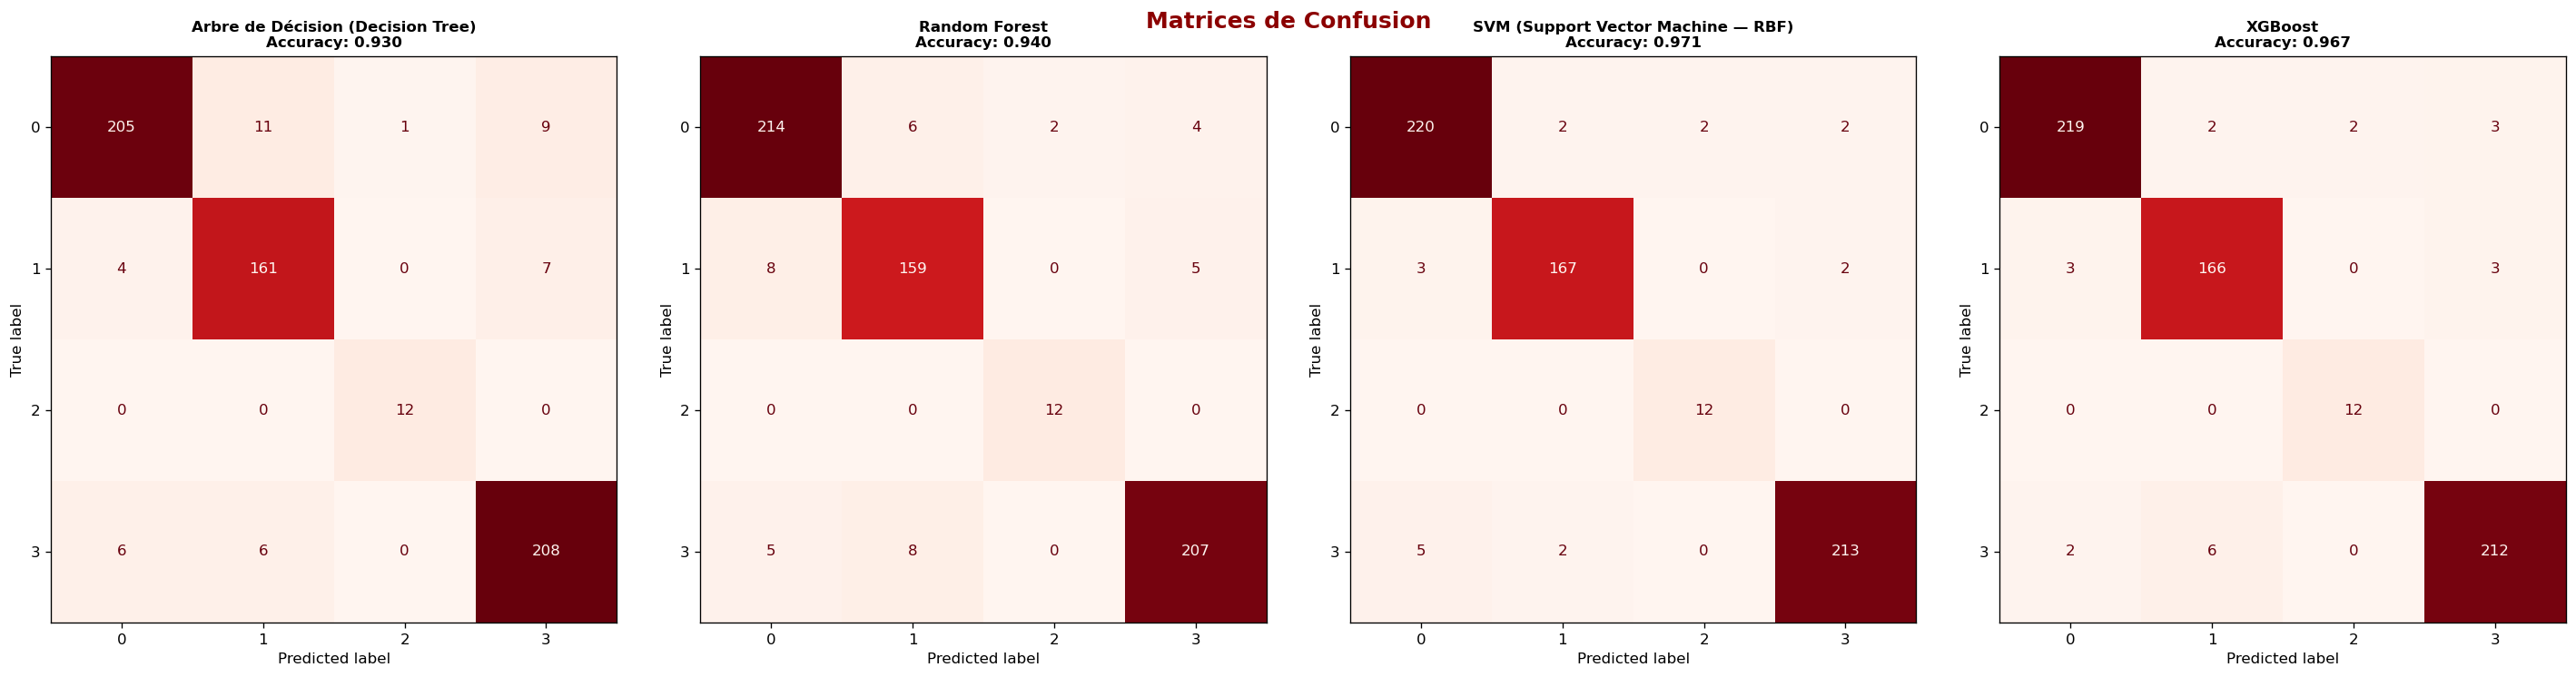

In [60]:
# ============================================================
# MATRICES DE CONFUSION
# ============================================================
n_models = len(ALL_RESULTS)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6))
if n_models == 1: axes = [axes]
fig.suptitle('Matrices de Confusion', fontsize=15, fontweight='bold', color='#8B0000')

for ax, result in zip(axes, ALL_RESULTS):
    disp = ConfusionMatrixDisplay(confusion_matrix=result['confusion_matrix'])
    disp.plot(ax=ax, colorbar=False, cmap='Reds')
    ax.set_title(f"{result['name']}\nAccuracy: {result['accuracy']:.3f}", 
                 fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

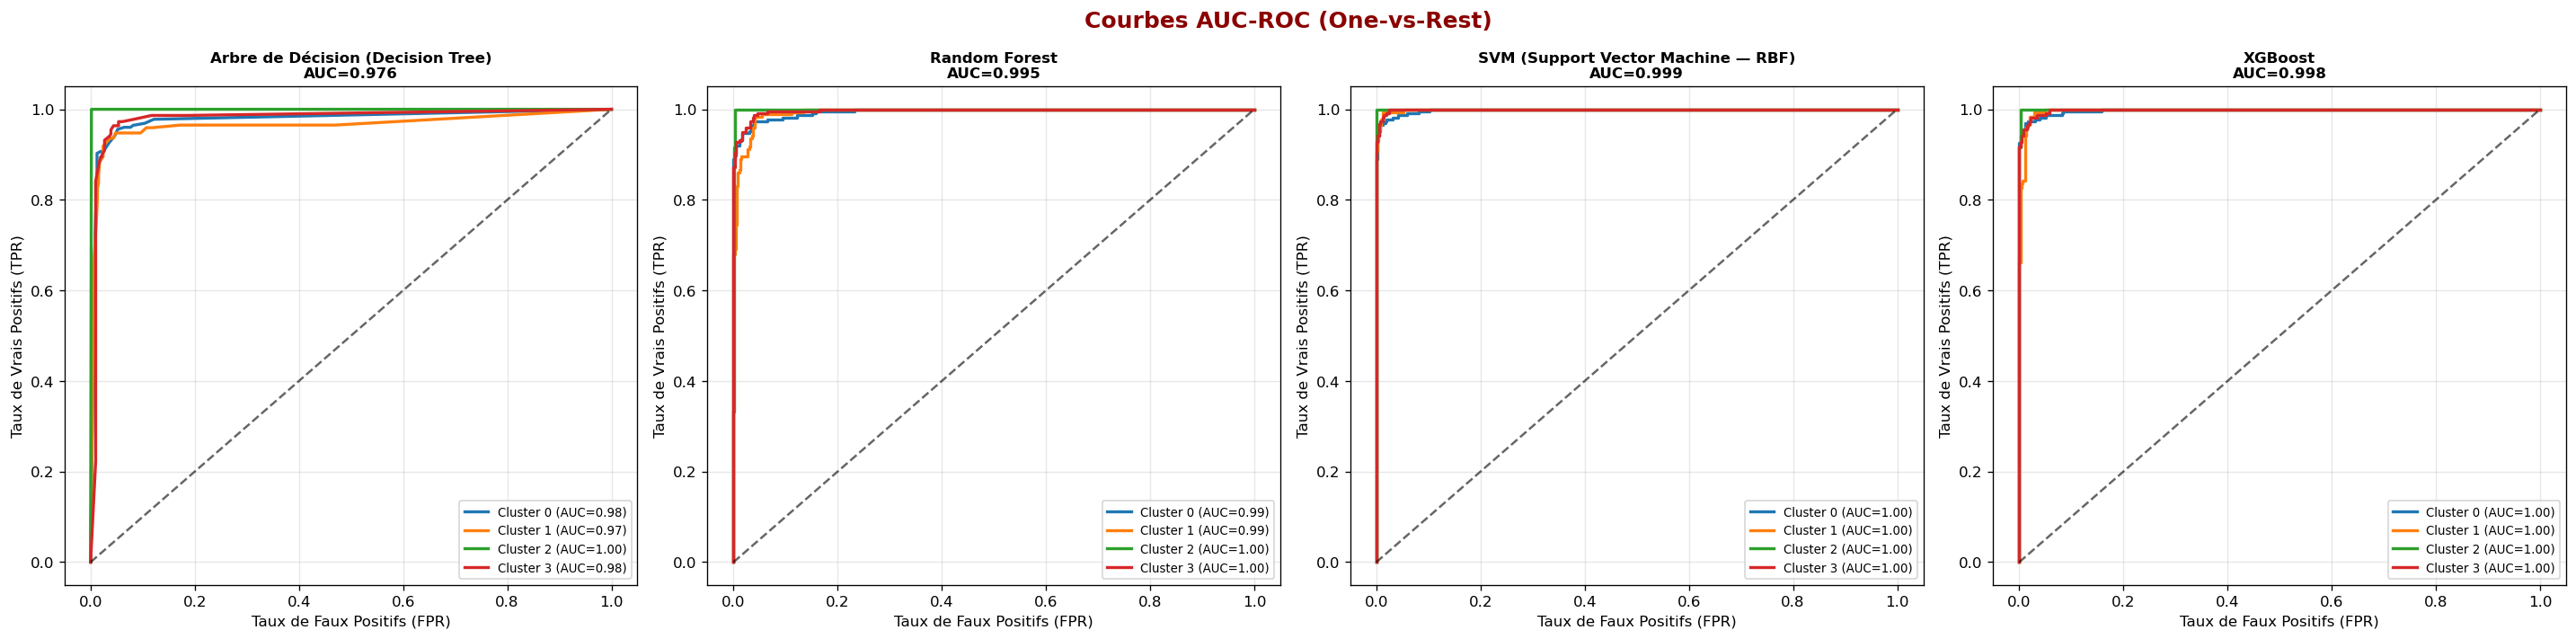

In [62]:
# ============================================================
# AUC - ROC CURVES
# ============================================================
from sklearn.preprocessing import label_binarize

classes = sorted(np.unique(y))
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6))
if n_models == 1: axes = [axes]
fig.suptitle('Courbes AUC-ROC (One-vs-Rest)', fontsize=15, fontweight='bold', color='#8B0000')

for ax, result in zip(axes, ALL_RESULTS):
    if result['y_prob'] is not None:
        for i, cls in enumerate(classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], result['y_prob'][:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, linewidth=2,
                    label=f'Cluster {cls} (AUC={roc_auc:.2f})')
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.6)
        ax.set_title(f"{result['name']}\nAUC={result['auc_roc']:.3f}", 
                     fontweight='bold', fontsize=10)
        ax.set_xlabel('Taux de Faux Positifs (FPR)')
        ax.set_ylabel('Taux de Vrais Positifs (TPR)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'AUC non disponible', ha='center', va='center')

plt.tight_layout()
plt.savefig('roc_auc_curves.png', bbox_inches='tight')
plt.show()

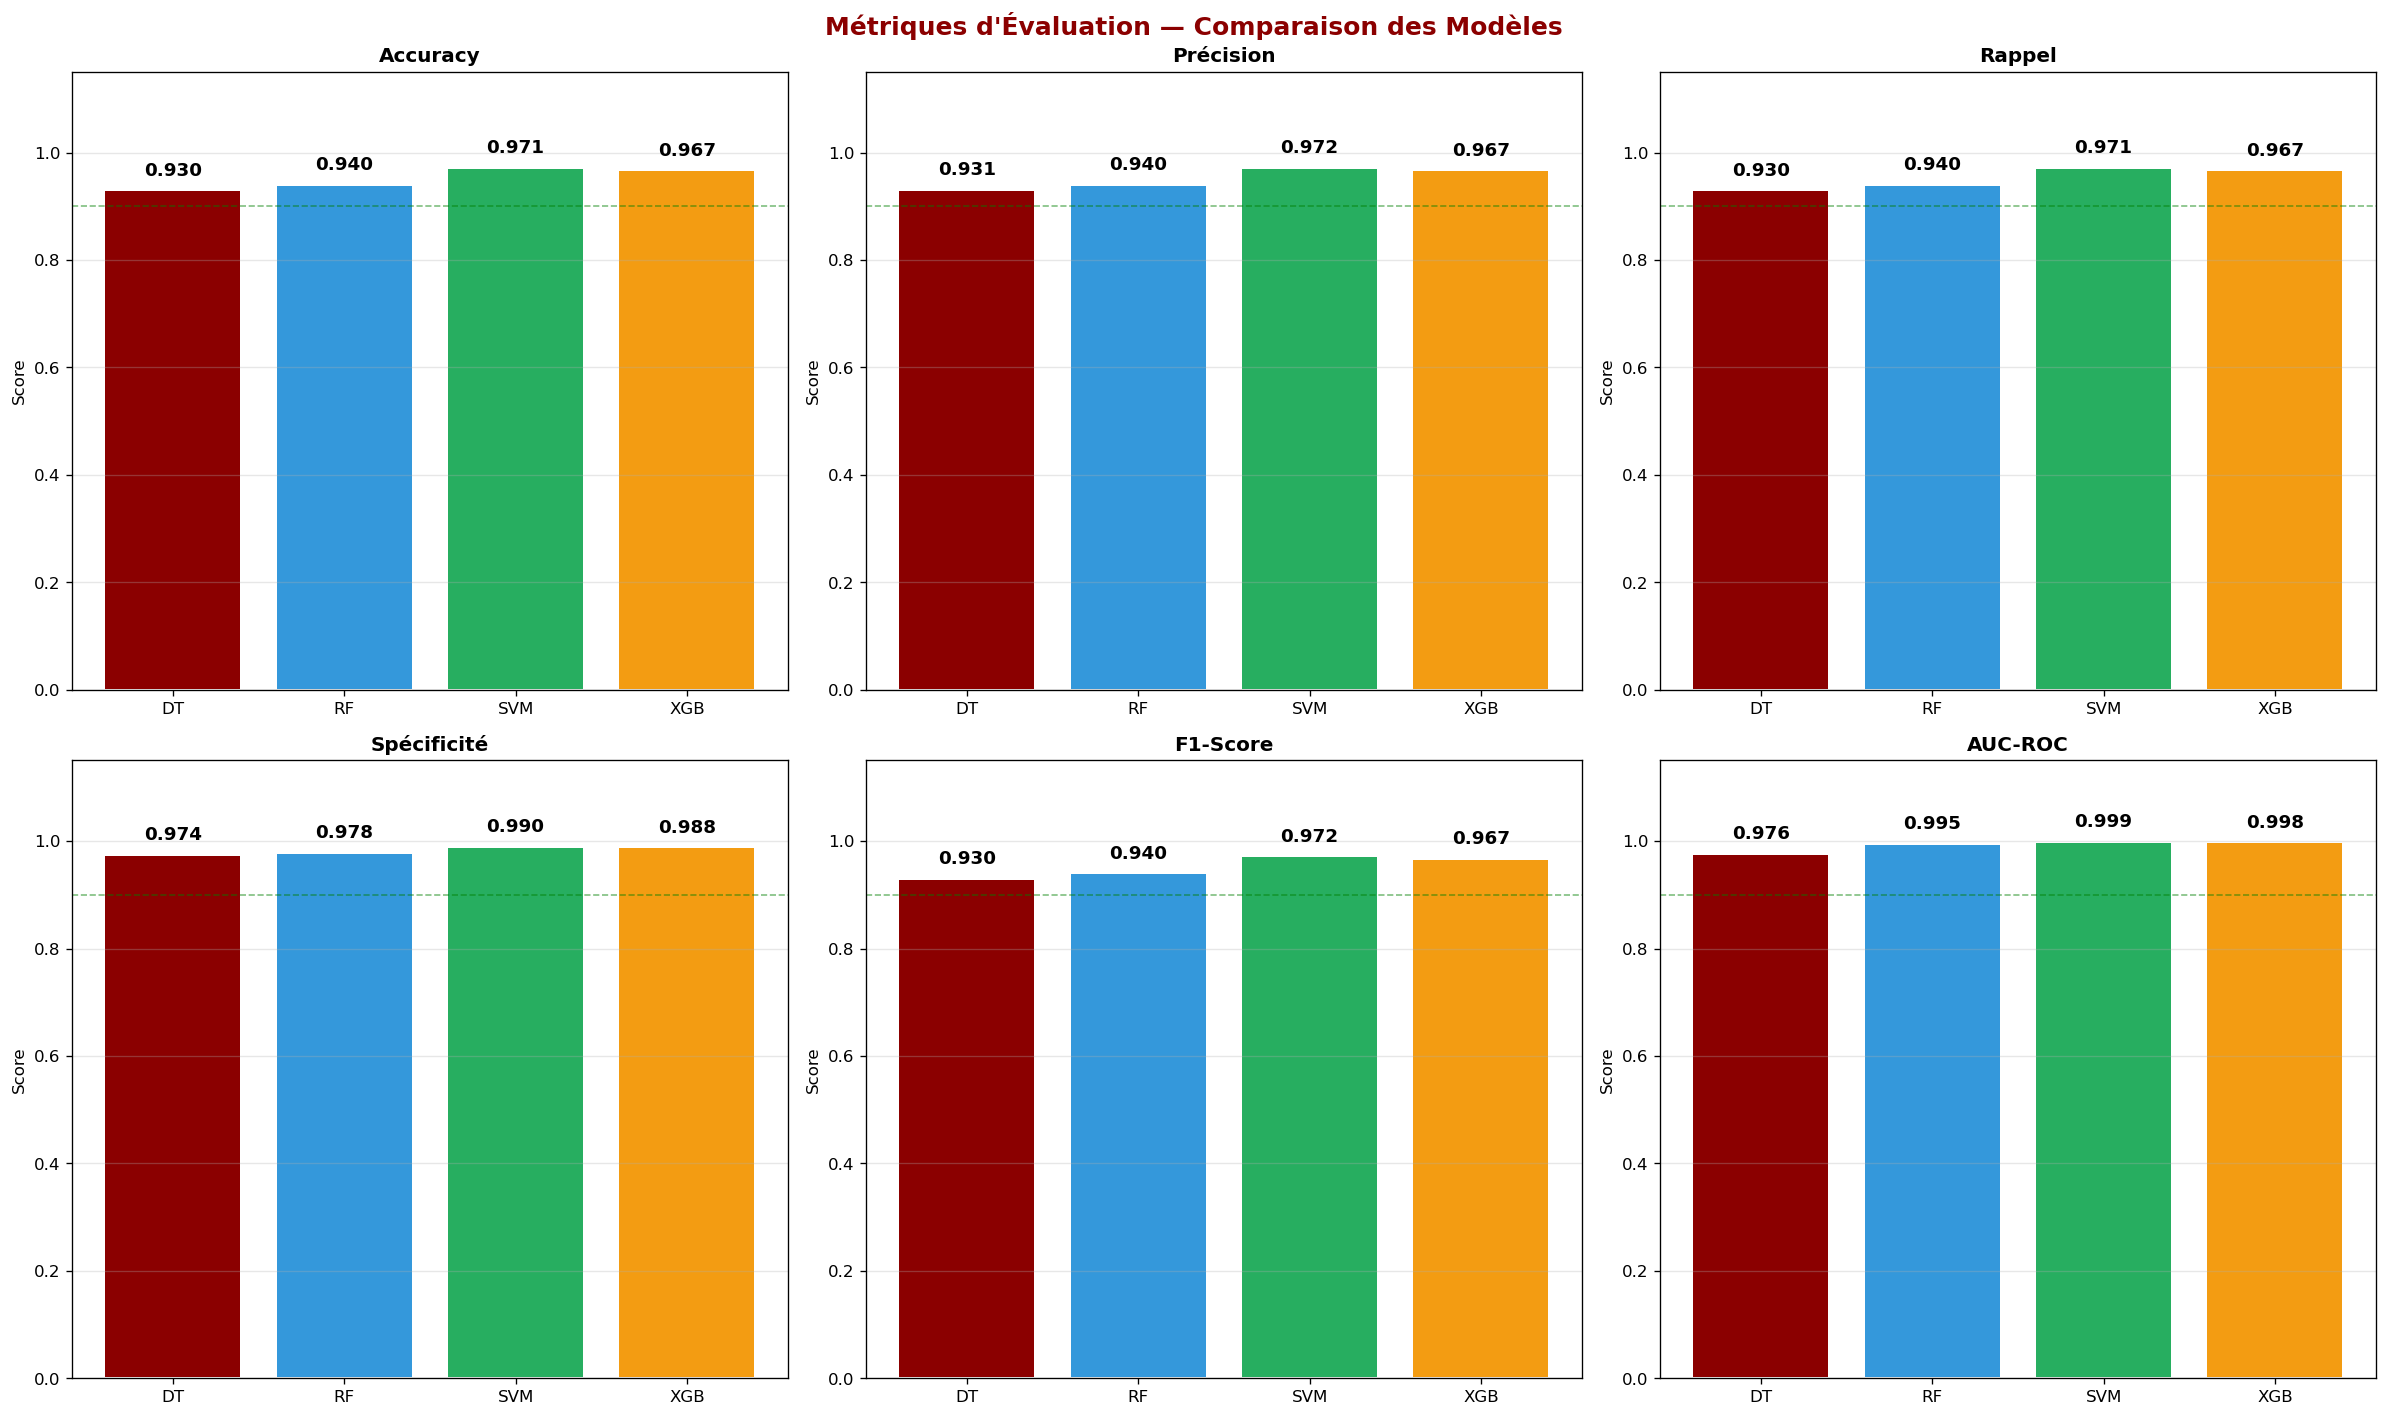

In [64]:
# ============================================================
# GRAPHIQUE COMPARATIF TOUTES MÉTRIQUES
# ============================================================
metrics_names = ['Accuracy', 'Précision', 'Rappel', 'Spécificité', 'F1-Score', 'AUC-ROC']
metrics_keys = ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'auc_roc']

model_names = [r['name'] for r in ALL_RESULTS]
model_short = ['DT', 'RF', 'SVM', 'XGB'][:n_models]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Métriques d\'Évaluation — Comparaison des Modèles', 
             fontsize=15, fontweight='bold', color='#8B0000')

bar_colors = ['#8B0000', '#3498DB', '#27AE60', '#F39C12']

for i, (metric_name, metric_key) in enumerate(zip(metrics_names, metrics_keys)):
    ax = axes[i//3, i%3]
    values = [r[metric_key] if r[metric_key] is not None else 0 for r in ALL_RESULTS]
    bars = ax.bar(model_short, values, color=bar_colors[:n_models], edgecolor='white', linewidth=1.2)
    ax.set_title(metric_name, fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, linewidth=1)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('metrics_comparison_all.png', bbox_inches='tight')
plt.show()

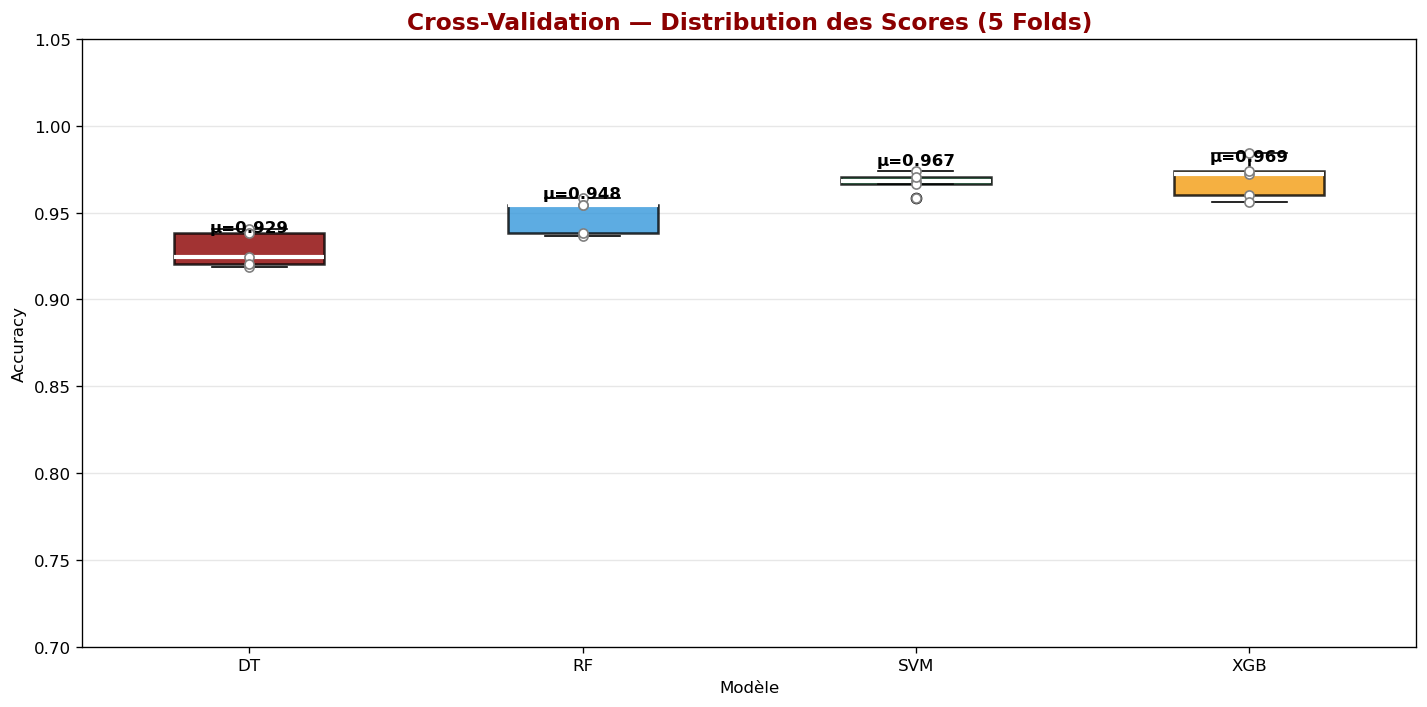

In [68]:
# ============================================================
# CROSS-VALIDATION — BOX PLOTS
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
cv_data = [r['cv_scores'] for r in ALL_RESULTS]
cv_labels = model_short

bp = ax.boxplot(cv_data, labels=cv_labels, patch_artist=True, notch=False,
                medianprops={'color': 'white', 'linewidth': 2.5},
                whiskerprops={'linewidth': 1.5},
                boxprops={'linewidth': 1.5})

for patch, color in zip(bp['boxes'], bar_colors[:n_models]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

for i, (data, label) in enumerate(zip(cv_data, cv_labels)):
    ax.scatter([i+1]*len(data), data, color='white', s=30, zorder=3, edgecolors='grey')

ax.set_title('Cross-Validation — Distribution des Scores (5 Folds)', 
             fontsize=14, fontweight='bold', color='#8B0000')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Modèle')
ax.set_ylim(0.7, 1.05)
ax.grid(axis='y', alpha=0.3)

# Afficher les moyennes
for i, r in enumerate(ALL_RESULTS):
    ax.text(i+1, r['cv_mean'] + 0.01, f"μ={r['cv_mean']:.3f}", 
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('cross_validation_boxplot.png', bbox_inches='tight')
plt.show()

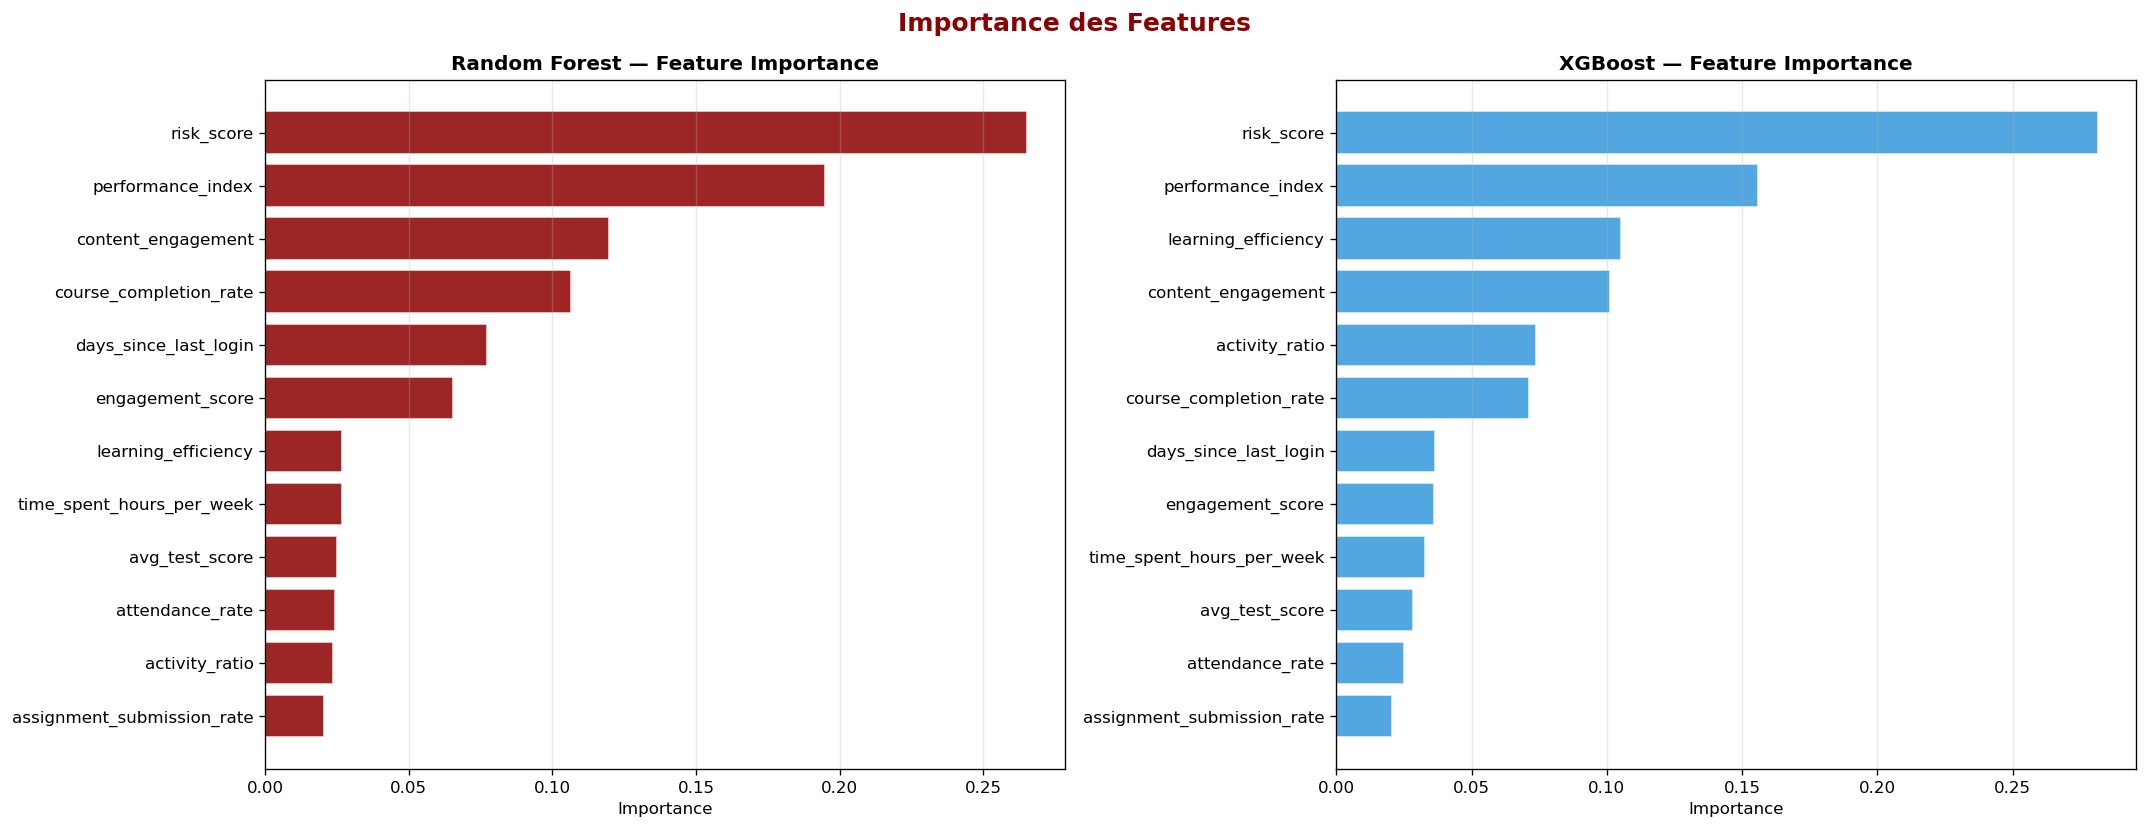

In [70]:
# ============================================================
# FEATURE IMPORTANCE (Random Forest & XGBoost)
# ============================================================
fig, axes = plt.subplots(1, 2 if XGBOOST_AVAILABLE else 1, figsize=(18, 7))
if not isinstance(axes, np.ndarray): axes = [axes]
fig.suptitle('Importance des Features', fontsize=15, fontweight='bold', color='#8B0000')

# Random Forest
importances_rf = result_rf['model'].feature_importances_
feat_imp_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances_rf})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True).tail(12)

axes[0].barh(feat_imp_df['Feature'], feat_imp_df['Importance'], 
             color='#8B0000', edgecolor='white', alpha=0.85)
axes[0].set_title('Random Forest — Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
if XGBOOST_AVAILABLE and len(axes) > 1:
    importances_xgb = result_xgb['model'].feature_importances_
    feat_imp_xgb = pd.DataFrame({'Feature': FEATURES, 'Importance': importances_xgb})
    feat_imp_xgb = feat_imp_xgb.sort_values('Importance', ascending=True).tail(12)
    axes[1].barh(feat_imp_xgb['Feature'], feat_imp_xgb['Importance'],
                 color='#3498DB', edgecolor='white', alpha=0.85)
    axes[1].set_title('XGBoost — Feature Importance', fontweight='bold')
    axes[1].set_xlabel('Importance')
    axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

## ⚖️ 10bis. Vérification de l'Équilibre des Classes (Balance des Clusters)

> Avant toute validation supervisée, il est indispensable de vérifier si les **clusters sont équilibrés** (même nombre d'étudiants par segment).
> Un dataset **déséquilibré** (imbalanced) biaiserait les métriques d'accuracy et nécessiterait un rééchantillonnage (SMOTE, under-sampling, etc.).

**Indices d'équilibre à analyser :**
- 📊 Distribution des clusters (effectifs + pourcentages)
- 📏 Ratio max/min : si > 1.5 → déséquilibre modéré ; si > 3 → déséquilibre sévère
- 📉 Coefficient de variation (CV) : si > 30% → déséquilibre


  ⚖️  ANALYSE D'ÉQUILIBRE DES CLUSTERS (BALANCE CHECK)
  Nombre de clusters   : 4
  Total d'étudiants    : 3150
  Distribution idéale  : 788 par cluster

  Cluster 0:  1129 étud. (35.8%)  █████████████████
  Cluster 1:   862 étud. (27.4%)  █████████████
  Cluster 2:    59 étud. (1.9%)  
  Cluster 3:  1100 étud. (34.9%)  █████████████████

  Ratio max/min          : 19.14  🔴 Déséquilibré
  Coeff. de variation    : 63.5%  ⚠️ Déséquilibré
  Test Chi² (p-value)    : 0.0000  ⚠️ Différence significative

  VERDICT : 🔴 UNBALANCED — Déséquilibre sévère. Appliquer SMOTE ou class_weight=balanced.


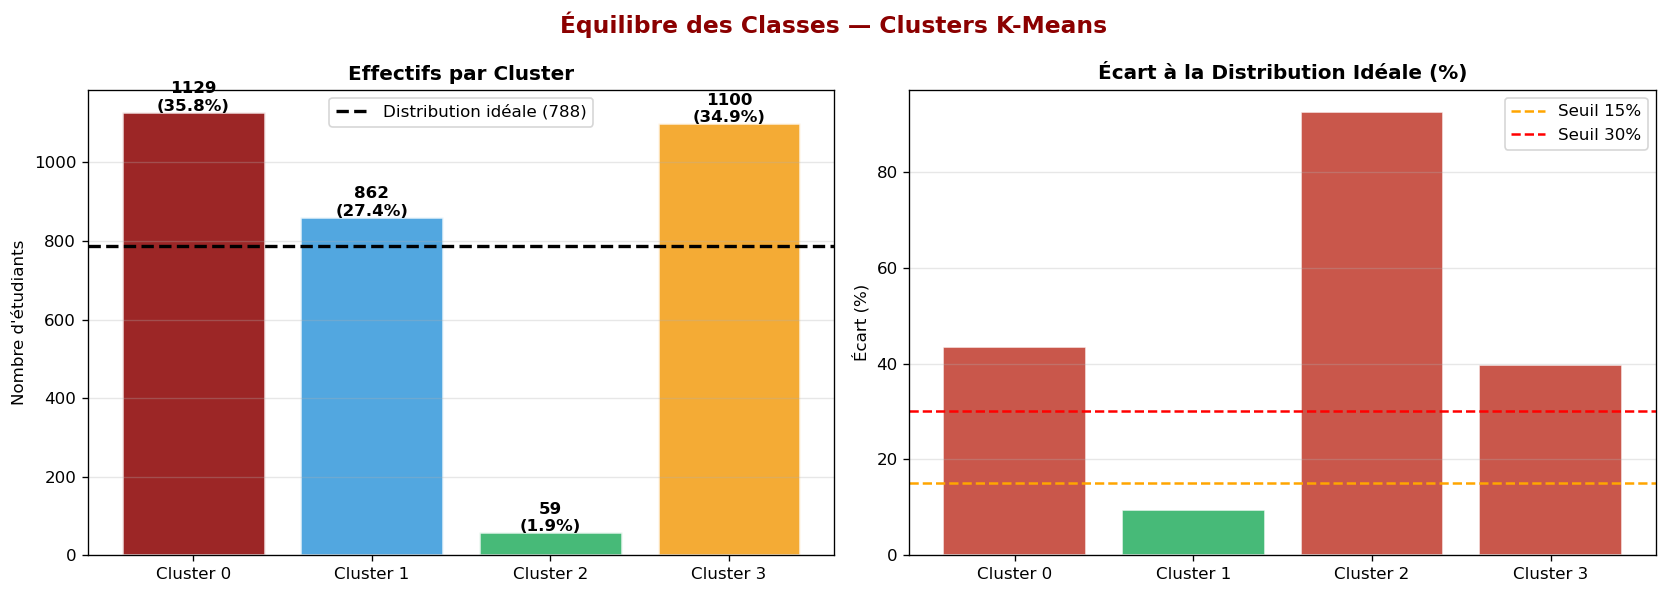

In [72]:
# ============================================================
# VÉRIFICATION ÉQUILIBRE DES CLASSES (CLUSTERS)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

cluster_counts = df['cluster_kmeans'].value_counts().sort_index()
total = len(df)
n_classes = len(cluster_counts)

# ── Métriques d'équilibre ──
ratio_max_min  = cluster_counts.max() / cluster_counts.min()
cv_balance     = (cluster_counts.std() / cluster_counts.mean()) * 100  # Coefficient de variation
expected_equal = total / n_classes
imbalance_pct  = abs(cluster_counts - expected_equal) / expected_equal * 100

# ── Test Chi² d'équilibre ──
chi2, p_value = chi2_contingency([cluster_counts.values, [expected_equal]*n_classes])[:2]

print('='*65)
print('  ⚖️  ANALYSE D\'ÉQUILIBRE DES CLUSTERS (BALANCE CHECK)')
print('='*65)
print(f'  Nombre de clusters   : {n_classes}')
print(f'  Total d\'étudiants    : {total}')
print(f'  Distribution idéale  : {expected_equal:.0f} par cluster')
print()
for c, count in cluster_counts.items():
    pct = count / total * 100
    bar = '█' * int(pct // 2)
    print(f'  Cluster {c}: {count:>5} étud. ({pct:.1f}%)  {bar}')
print()
print(f'  Ratio max/min          : {ratio_max_min:.2f}  ', end='')
print('✅ Équilibré' if ratio_max_min <= 1.5 else ('⚠️ Modéré' if ratio_max_min <= 3 else '🔴 Déséquilibré'))
print(f'  Coeff. de variation    : {cv_balance:.1f}%  ', end='')
print('✅ Équilibré' if cv_balance <= 30 else '⚠️ Déséquilibré')
print(f'  Test Chi² (p-value)    : {p_value:.4f}  ', end='')
print('✅ Pas de diff. signif.' if p_value > 0.05 else '⚠️ Différence significative')

# ── Décision ──
print()
if ratio_max_min <= 1.5 and cv_balance <= 30:
    verdict = '✅ BALANCED — Le dataset est équilibré. Aucun rééchantillonnage nécessaire.'
elif ratio_max_min <= 3:
    verdict = '⚠️ SLIGHTLY UNBALANCED — Déséquilibre modéré. Préférer F1-Score & AUC-ROC vs Accuracy.'
else:
    verdict = '🔴 UNBALANCED — Déséquilibre sévère. Appliquer SMOTE ou class_weight=balanced.'
print('  VERDICT :', verdict)
print('='*65)

# ── Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Équilibre des Classes — Clusters K-Means', fontsize=14, fontweight='bold', color='#8B0000')

# Bar chart
bar_colors_bal = ['#8B0000', '#3498DB', '#27AE60', '#F39C12']
bars = axes[0].bar(
    [f'Cluster {c}' for c in cluster_counts.index], cluster_counts.values,
    color=bar_colors_bal[:n_classes], edgecolor='white', linewidth=1.5, alpha=0.85
)
axes[0].axhline(expected_equal, color='black', linestyle='--', linewidth=2, label=f'Distribution idéale ({expected_equal:.0f})')
for bar, val in zip(bars, cluster_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val}\n({val/total*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Effectifs par Cluster', fontweight='bold')
axes[0].set_ylabel('Nombre d\'étudiants')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Deviation from ideal
colors_dev = ['#27AE60' if v <= 15 else '#F39C12' if v <= 30 else '#C0392B' for v in imbalance_pct]
axes[1].bar([f'Cluster {c}' for c in imbalance_pct.index], imbalance_pct.values,
            color=colors_dev, edgecolor='white', alpha=0.85)
axes[1].axhline(15, color='orange', linestyle='--', linewidth=1.5, label='Seuil 15%')
axes[1].axhline(30, color='red', linestyle='--', linewidth=1.5, label='Seuil 30%')
axes[1].set_title('Écart à la Distribution Idéale (%)', fontweight='bold')
axes[1].set_ylabel('Écart (%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_balance_check.png', bbox_inches='tight')
plt.show()

### 📝 Interprétation — Équilibre des Classes

| Indicateur | Valeur | Interprétation |
|---|---|---|
| **Ratio max/min** | Calculé ci-dessus | ≤ 1.5 = équilibré ✅ / > 3 = déséquilibré 🔴 |
| **Coeff. de variation** | Calculé ci-dessus | ≤ 30% = équilibré ✅ |
| **Test Chi²** | p-value | > 0.05 = pas de différence significative |

**Si BALANCED ✅** : L'accuracy est une métrique fiable. Les modèles ne sont pas biaisés vers un cluster majoritaire.

**Si UNBALANCED ⚠️** : Privilegier le F1-Score macro et l'AUC-ROC. Envisager `class_weight='balanced'` dans les classifieurs.


## 🔍 10ter. Grid Search — Optimisation des Hyperparamètres

> **Grid Search** (recherche sur grille) explore **toutes les combinaisons** de paramètres pour trouver le modèle le plus performant.
> Combiné avec la **cross-validation**, il garantit que les hyperparamètres choisis généralisent bien (et non du surapprentissage).

**Modèles optimisés :** Decision Tree · Random Forest · SVM · XGBoost


In [74]:
# ============================================================
# GRID SEARCH — OPTIMISATION DES HYPERPARAMÈTRES
# ============================================================
from sklearn.model_selection import GridSearchCV
import time

print('🔍 Grid Search en cours... (patience ⏳)\n')

cv_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs_results = {}

# ── 1. Decision Tree ──────────────────────────────────────────
param_grid_dt = {
    'max_depth'        : [4, 6, 8, 10, None],
    'min_samples_split': [10, 20, 50],
    'criterion'        : ['gini', 'entropy'],
}
t0 = time.time()
gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt,
                     cv=cv_gs, scoring='f1_weighted', n_jobs=-1, verbose=0)
gs_dt.fit(X_train, y_train)
gs_results['Decision Tree'] = gs_dt
print(f'✅ Decision Tree  — Best params: {gs_dt.best_params_}  |  CV F1: {gs_dt.best_score_:.4f}  ({time.time()-t0:.1f}s)')

# ── 2. Random Forest ──────────────────────────────────────────
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth'   : [8, 12, None],
    'max_features': ['sqrt', 'log2'],
}
t0 = time.time()
gs_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid_rf,
                     cv=cv_gs, scoring='f1_weighted', n_jobs=-1, verbose=0)
gs_rf.fit(X_train, y_train)
gs_results['Random Forest'] = gs_rf
print(f'✅ Random Forest  — Best params: {gs_rf.best_params_}  |  CV F1: {gs_rf.best_score_:.4f}  ({time.time()-t0:.1f}s)')

# ── 3. SVM ────────────────────────────────────────────────────
param_grid_svm = {
    'C'      : [1, 10, 50],
    'kernel' : ['rbf', 'linear'],
    'gamma'  : ['scale', 'auto'],
}
t0 = time.time()
gs_svm = GridSearchCV(SVC(random_state=42, probability=True), param_grid_svm,
                      cv=cv_gs, scoring='f1_weighted', n_jobs=-1, verbose=0)
gs_svm.fit(X_train, y_train)
gs_results['SVM'] = gs_svm
print(f'✅ SVM            — Best params: {gs_svm.best_params_}  |  CV F1: {gs_svm.best_score_:.4f}  ({time.time()-t0:.1f}s)')

# ── 4. XGBoost ────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    param_grid_xgb = {
        'n_estimators'  : [100, 200],
        'max_depth'     : [4, 6, 8],
        'learning_rate' : [0.05, 0.1, 0.2],
    }
    t0 = time.time()
    gs_xgb = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0, use_label_encoder=False),
        param_grid_xgb, cv=cv_gs, scoring='f1_weighted', n_jobs=-1, verbose=0
    )
    gs_xgb.fit(X_train, y_train)
    gs_results['XGBoost'] = gs_xgb
    print(f'✅ XGBoost        — Best params: {gs_xgb.best_params_}  |  CV F1: {gs_xgb.best_score_:.4f}  ({time.time()-t0:.1f}s)')

print('\n✅ Grid Search terminé !')

🔍 Grid Search en cours... (patience ⏳)

✅ Decision Tree  — Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}  |  CV F1: 0.9337  (4.4s)
✅ Random Forest  — Best params: {'max_depth': 12, 'max_features': 'sqrt', 'n_estimators': 100}  |  CV F1: 0.9512  (10.3s)
✅ SVM            — Best params: {'C': 50, 'gamma': 'scale', 'kernel': 'linear'}  |  CV F1: 0.9929  (4.6s)
✅ XGBoost        — Best params: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}  |  CV F1: 0.9710  (13.1s)

✅ Grid Search terminé !


In [76]:
# ============================================================
# ÉVALUATION DES MEILLEURS MODÈLES (POST GRID SEARCH)
# ============================================================
from sklearn.metrics import f1_score, accuracy_score

print('\n' + '='*75)
print('  📊 COMPARAISON : AVANT vs APRÈS Grid Search')
print('='*75)
print(f'  {"Modèle":<25} | {"F1 Avant":>10} | {"F1 Après GS":>12} | {"Gain":>8} | Meilleurs Params')
print('-'*75)

before = {'Decision Tree': result_dt, 'Random Forest': result_rf, 'SVM': result_svm}
if XGBOOST_AVAILABLE: before['XGBoost'] = result_xgb

best_gs_results = []
for name, gs in gs_results.items():
    best_model = gs.best_estimator_
    best_model.fit(X_train, y_train)
    y_pred_gs = best_model.predict(X_test)
    f1_after  = f1_score(y_test, y_pred_gs, average='weighted')
    f1_before = before[name]['f1']
    gain      = f1_after - f1_before
    gain_str  = f'+{gain:.4f}' if gain >= 0 else f'{gain:.4f}'
    print(f'  {name:<25} | {f1_before:>10.4f} | {f1_after:>12.4f} | {gain_str:>8} | {gs.best_params_}')
    best_gs_results.append({'name': name, 'model': best_model, 'f1': f1_after,
                             'accuracy': accuracy_score(y_test, y_pred_gs),
                             'params': gs.best_params_})

print('='*75)
best_gs = max(best_gs_results, key=lambda x: x['f1'])
print(f'\n🏆 MEILLEUR MODÈLE POST-GRIDSEARCH : {best_gs["name"]}')
print(f'   F1-Score  : {best_gs["f1"]:.4f}')
print(f'   Accuracy  : {best_gs["accuracy"]:.4f}')
print(f'   Params    : {best_gs["params"]}')


  📊 COMPARAISON : AVANT vs APRÈS Grid Search
  Modèle                    |   F1 Avant |  F1 Après GS |     Gain | Meilleurs Params
---------------------------------------------------------------------------
  Decision Tree             |     0.9302 |       0.9270 |  -0.0032 | {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}
  Random Forest             |     0.9398 |       0.9381 |  -0.0016 | {'max_depth': 12, 'max_features': 'sqrt', 'n_estimators': 100}
  SVM                       |     0.9715 |       0.9906 |  +0.0191 | {'C': 50, 'gamma': 'scale', 'kernel': 'linear'}
  XGBoost                   |     0.9668 |       0.9620 |  -0.0048 | {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}

🏆 MEILLEUR MODÈLE POST-GRIDSEARCH : SVM
   F1-Score  : 0.9906
   Accuracy  : 0.9905
   Params    : {'C': 50, 'gamma': 'scale', 'kernel': 'linear'}


### 📝 Interprétation — Grid Search

Le Grid Search explore **systématiquement** toutes les combinaisons de paramètres définis dans la grille :

| Modèle | Paramètres optimisés | Impact |
|--------|---------------------|--------|
| **Decision Tree** | `max_depth`, `min_samples_split`, `criterion` | Contrôle la complexité et l'overfitting |
| **Random Forest** | `n_estimators`, `max_depth`, `max_features` | Équilibre biais-variance |
| **SVM** | `C`, `kernel`, `gamma` | Marge de décision et transformation |
| **XGBoost** | `n_estimators`, `max_depth`, `learning_rate` | Vitesse d'apprentissage et profondeur |

**Le gain de F1 post-GridSearch** indique la marge d'amélioration apportée par l'optimisation des hyperparamètres.
Un gain faible (< 0.01) confirme que les paramètres initiaux étaient déjà bien choisis.


## 🔎 10quater. Détection Overfitting / Underfitting

> Comparer les performances sur les données **d'entraînement** vs **de test** permet de détecter :
> - **Overfitting (surapprentissage)** : train >> test → le modèle mémorise au lieu de généraliser
> - **Underfitting (sous-apprentissage)** : train ≈ test mais les deux sont faibles → modèle trop simple
> - **Bonne généralisation** : train ≈ test avec des valeurs élevées

**Règle pratique :** si `train_score - test_score > 0.05` → risque d'overfitting.


  🔎 ANALYSE OVERFITTING / UNDERFITTING
  Modèle                              |  Train F1 |  Test F1 |     Gap | Diagnostic
------------------------------------------------------------------------
  Arbre de Décision (Decision Tree)   |    0.9702 |   0.9302 | +0.0401 | ✅ BIEN GÉNÉRALISÉ
  Random Forest                       |    1.0000 |   0.9398 | +0.0602 | ⚠️ LÉGÈRE VARIANCE
  SVM (Support Vector Machine — RBF)  |    0.9992 |   0.9715 | +0.0277 | ✅ BIEN GÉNÉRALISÉ
  XGBoost                             |    1.0000 |   0.9668 | +0.0332 | ✅ BIEN GÉNÉRALISÉ
  Seuil overfitting : gap > 0.10 | Seuil underfitting : test F1 < 0.70


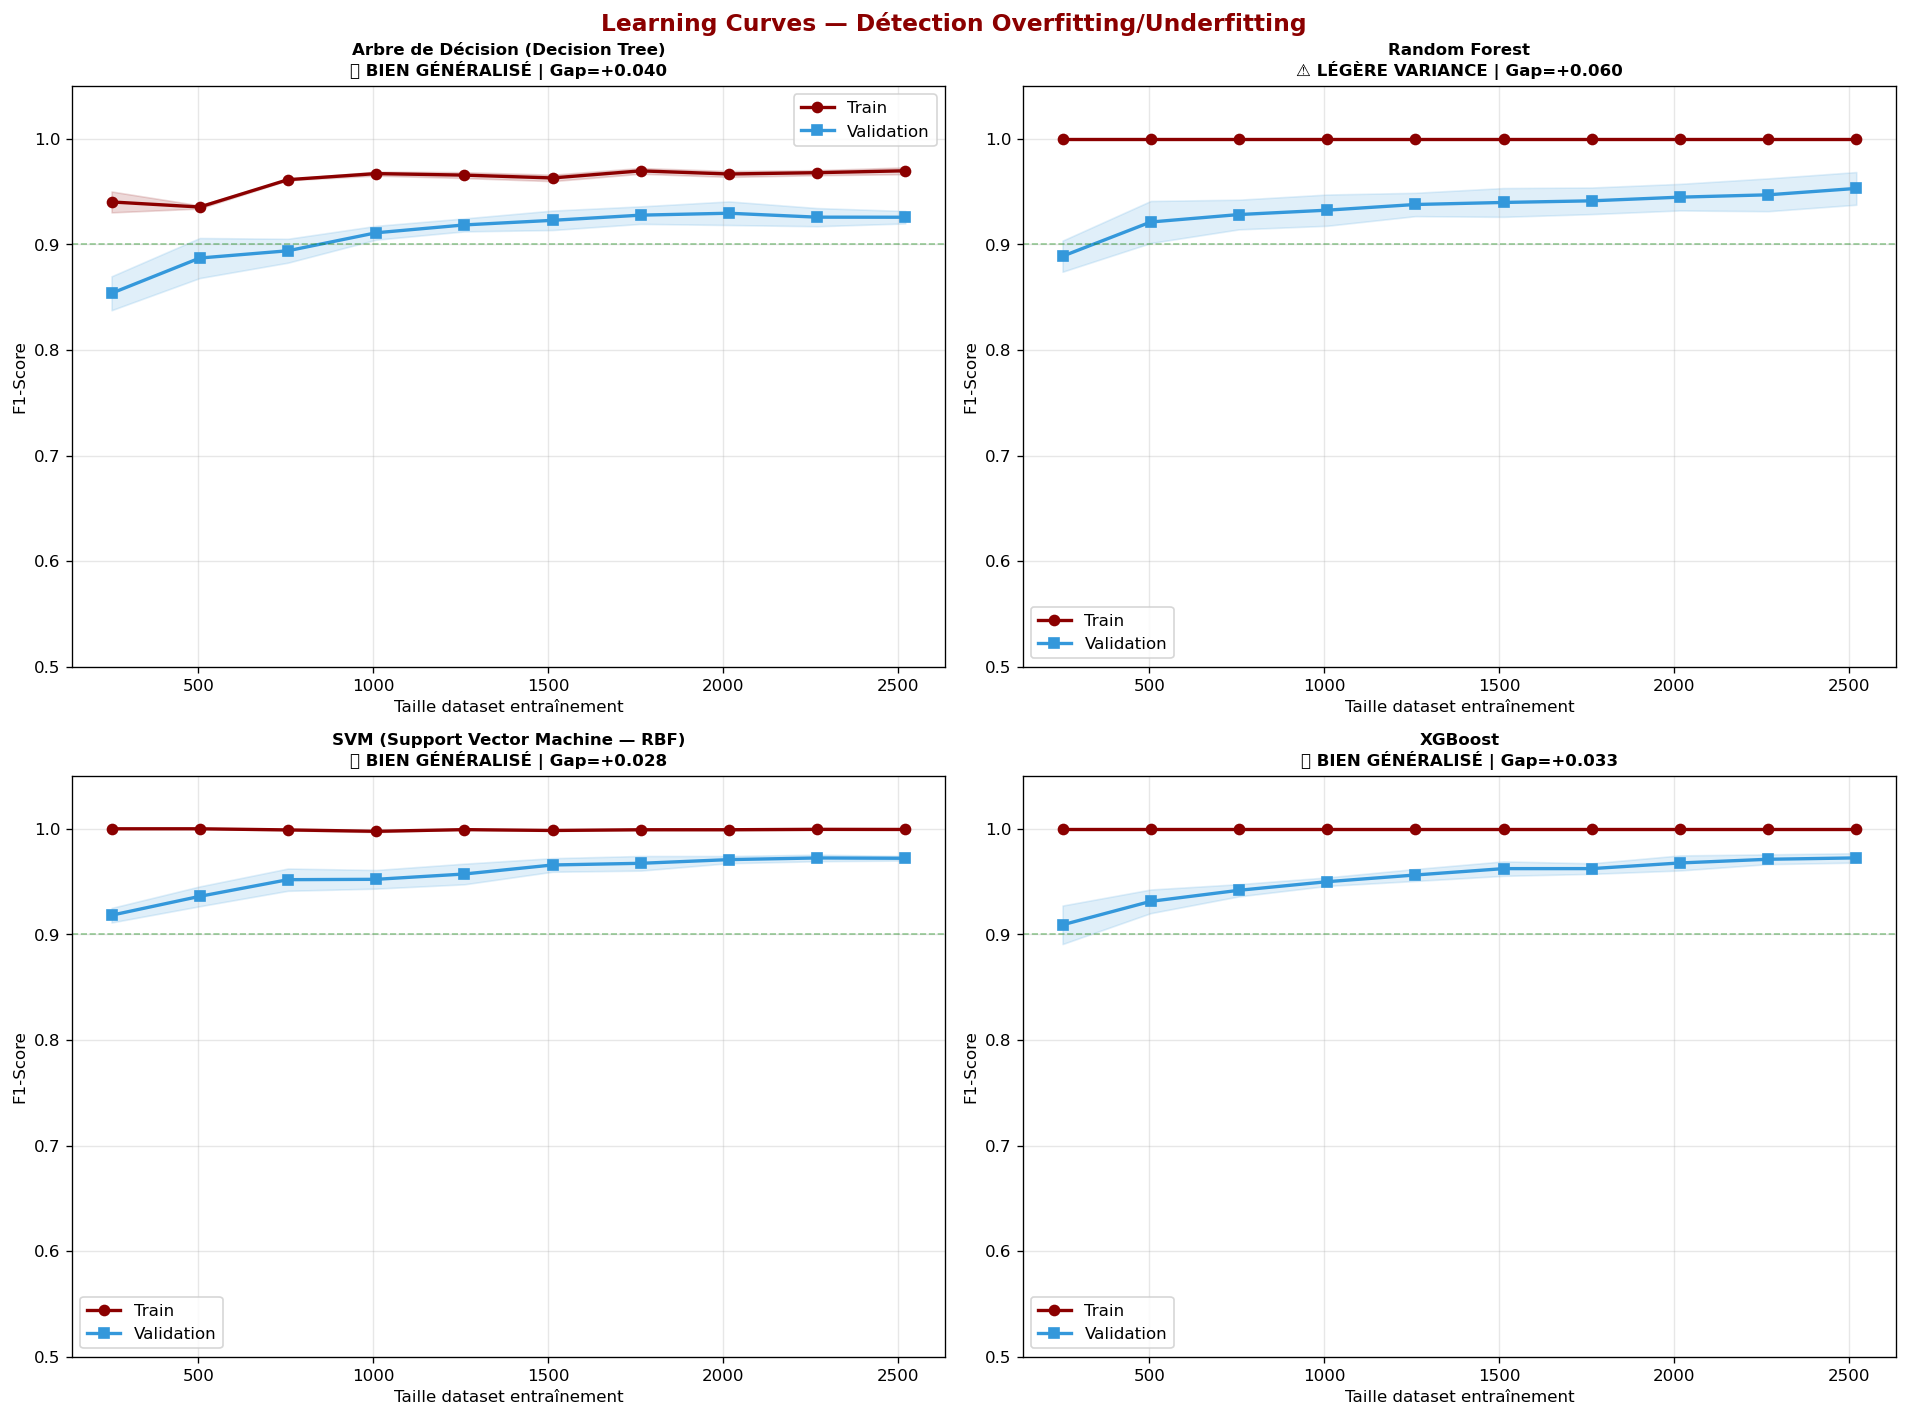

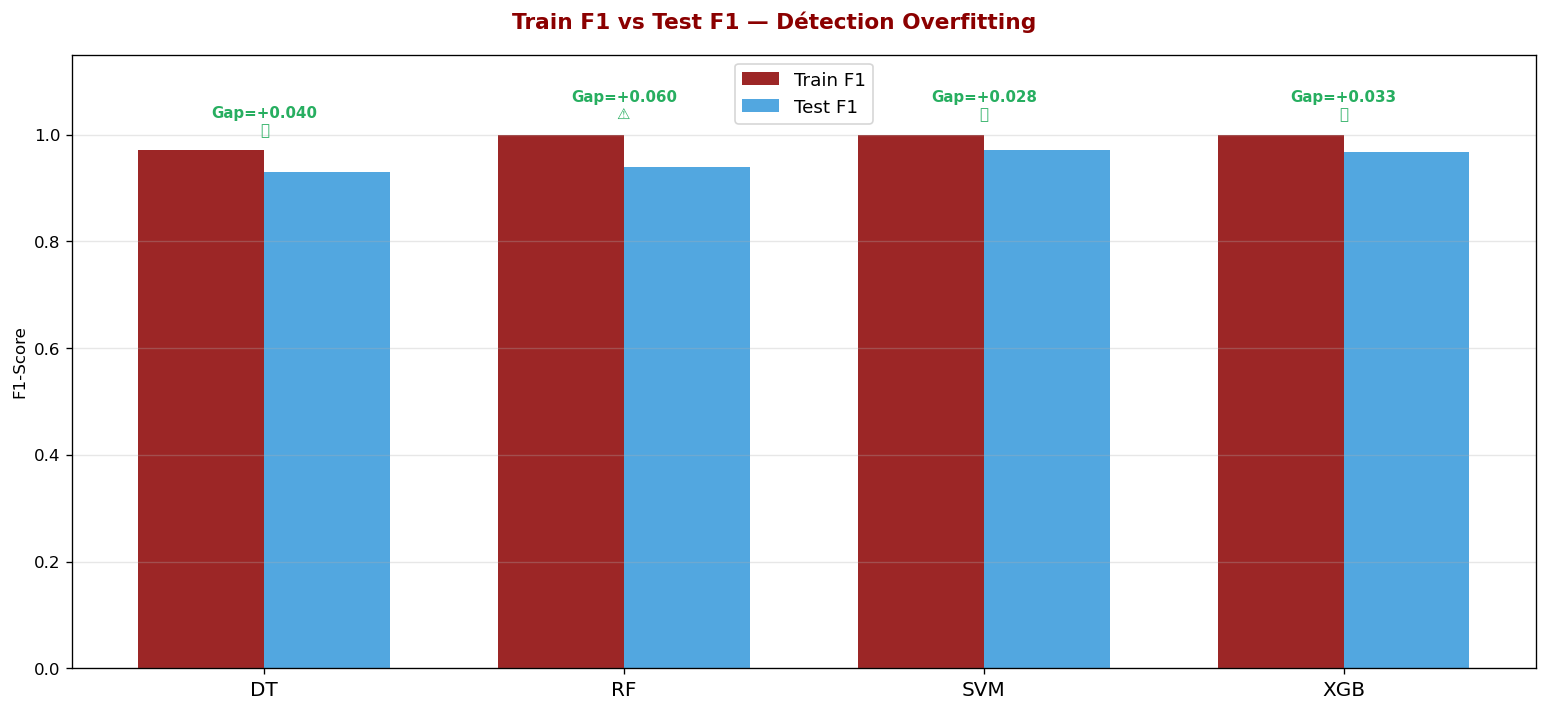

In [78]:
# ============================================================
# DÉTECTION OVERFITTING / UNDERFITTING
# ============================================================
from sklearn.metrics import f1_score

print('='*72)
print('  🔎 ANALYSE OVERFITTING / UNDERFITTING')
print('='*72)
print(f'  {"Modèle":<35} | {"Train F1":>9} | {"Test F1":>8} | {"Gap":>7} | Diagnostic')
print('-'*72)

overfit_data = []
for r in ALL_RESULTS:
    model = r['model']
    y_pred_train = model.predict(X_train)
    train_f1 = f1_score(y_train, y_pred_train, average='weighted')
    test_f1  = r['f1']
    gap      = train_f1 - test_f1
    
    if gap > 0.10:
        diag = '🔴 OVERFITTING'
    elif test_f1 < 0.70:
        diag = '🟡 UNDERFITTING'
    elif gap <= 0.05:
        diag = '✅ BIEN GÉNÉRALISÉ'
    else:
        diag = '⚠️ LÉGÈRE VARIANCE'
    
    overfit_data.append({'name': r['name'], 'train_f1': train_f1, 'test_f1': test_f1, 'gap': gap, 'diag': diag})
    name_short = r['name'][:35]
    print(f'  {name_short:<35} | {train_f1:>9.4f} | {test_f1:>8.4f} | {gap:>+7.4f} | {diag}')

print('='*72)
print('  Seuil overfitting : gap > 0.10 | Seuil underfitting : test F1 < 0.70')

# ── Visualisation Learning Curve ──────────────────────────────
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Learning Curves — Détection Overfitting/Underfitting',
             fontsize=14, fontweight='bold', color='#8B0000')

for idx, r in enumerate(ALL_RESULTS):
    ax = axes[idx // 2, idx % 2]
    train_sizes, train_scores, test_scores = learning_curve(
        r['model'], X_clf, y, cv=5, scoring='f1_weighted',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    test_mean  = test_scores.mean(axis=1)
    test_std   = test_scores.std(axis=1)
    
    ax.plot(train_sizes, train_mean, 'o-', color='#8B0000', label='Train', linewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#8B0000')
    ax.plot(train_sizes, test_mean, 's-', color='#3498DB', label='Validation', linewidth=2)
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#3498DB')
    
    # Annotations
    od = next(d for d in overfit_data if d['name'] == r['name'])
    ax.set_title(f"{r['name']}\n{od['diag']} | Gap={od['gap']:+.3f}", fontweight='bold', fontsize=10)
    ax.set_xlabel('Taille dataset entraînement')
    ax.set_ylabel('F1-Score')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.5, 1.05)
    ax.axhline(0.9, color='green', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig('learning_curves_overfit.png', bbox_inches='tight')
plt.show()

# ── Bar chart Train vs Test ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('Train F1 vs Test F1 — Détection Overfitting', fontsize=13, fontweight='bold', color='#8B0000')

names_short = ['DT', 'RF', 'SVM', 'XGB'][:len(ALL_RESULTS)]
x = np.arange(len(ALL_RESULTS))
w = 0.35
ax.bar(x - w/2, [d['train_f1'] for d in overfit_data], w, label='Train F1', color='#8B0000', alpha=0.85)
ax.bar(x + w/2, [d['test_f1']  for d in overfit_data], w, label='Test F1',  color='#3498DB', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names_short, fontsize=12)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.15)
ax.axhline(0.05, color='red', linestyle='--', alpha=0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for i, d in enumerate(overfit_data):
    gap_color = '#C0392B' if d['gap'] > 0.10 else '#27AE60'
    ax.annotate(f"Gap={d['gap']:+.3f}\n{d['diag'].split()[0]}",
                xy=(i, max(d['train_f1'], d['test_f1']) + 0.03),
                ha='center', fontsize=9, fontweight='bold', color=gap_color)

plt.tight_layout()
plt.savefig('overfitting_bar.png', bbox_inches='tight')
plt.show()

### 📝 Interprétation — Overfitting / Underfitting

| Diagnostic | Condition | Action corrective |
|-----------|-----------|------------------|
| ✅ **Bien généralisé** | Gap ≤ 5% ET Test F1 ≥ 90% | Aucune action, modèle déployable |
| ⚠️ **Légère variance** | Gap entre 5% et 10% | Augmenter les données ou régulariser légèrement |
| 🔴 **Overfitting** | Gap > 10% | Réduire `max_depth`, augmenter `min_samples`, appliquer pruning |
| 🟡 **Underfitting** | Test F1 < 70% | Augmenter la complexité du modèle, ajouter des features |

**Learning Curve :** si les courbes Train et Validation **convergent** vers une valeur élevée → le modèle généralise bien.
Si elles restent **écartées** → overfitting. Si elles sont toutes deux basses → underfitting.


## 📋 12. Tableau Récapitulatif — BO / DSO / Algorithmes

In [80]:
# ============================================================
# TABLEAU RÉCAPITULATIF FINAL
# ============================================================

# 12.1 — Tableau BO / DSO / Algorithmes
print("\n" + "=" * 100)
print("📊  TABLEAU RÉCAPITULATIF — MODÈLE 1 : CLUSTERING K-MEANS | EnglishForU")
print("=" * 100)

summary_table = pd.DataFrame({
    'Objectif Métier (BO)': [
        'Augmenter l\'engagement moyen de 20%',
        'Augmenter l\'engagement moyen de 20%',
        'Augmenter l\'engagement moyen de 20%',
        'Augmenter l\'engagement moyen de 20%',
    ],
    'Objectif Data Science (DSO)': [
        'Segmenter étudiants par comportement',
        'Segmenter étudiants par comportement',
        'Segmenter étudiants par comportement',
        'Segmenter étudiants par comportement',
    ],
    'Algorithme': ['K-Means', 'DBSCAN', 'Agglomerative Clustering', 'Gaussian Mixture Model'],
    'Silhouette ↑': [round(sil_km,4), round(sil_db,4), round(sil_ag,4), round(sil_gm,4)],
    'Davies-Bouldin ↓': [round(db_km,4), round(db_db,4), round(db_ag,4), round(db_gm,4)],
    'N Clusters': [BEST_K, n_clusters_db, BEST_K, BEST_K],
    'Recommandé ?': [
        '✅ Meilleur compromis',
        '⚠️ Sensible aux outliers',
        '✅ Bon (pas de scalabilité)',
        '✅ Probabiliste (souple)'
    ]
})
print(summary_table.to_string(index=False))

print("\n" + "=" * 100)
print("📊  TABLEAU RÉCAPITULATIF — VALIDATION SUPERVISÉE")
print("=" * 100)

clf_table = pd.DataFrame({
    'Algorithme': [r['name'] for r in ALL_RESULTS],
    'Accuracy': [f"{r['accuracy']:.4f}" for r in ALL_RESULTS],
    'Précision': [f"{r['precision']:.4f}" for r in ALL_RESULTS],
    'Rappel': [f"{r['recall']:.4f}" for r in ALL_RESULTS],
    'Spécificité': [f"{r['specificity']:.4f}" for r in ALL_RESULTS],
    'F1-Score': [f"{r['f1']:.4f}" for r in ALL_RESULTS],
    'AUC-ROC': [f"{r['auc_roc']:.4f}" if r['auc_roc'] else 'N/A' for r in ALL_RESULTS],
    'CV Accuracy': [f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}" for r in ALL_RESULTS],
})
print(clf_table.to_string(index=False))


📊  TABLEAU RÉCAPITULATIF — MODÈLE 1 : CLUSTERING K-MEANS | EnglishForU
               Objectif Métier (BO)          Objectif Data Science (DSO)               Algorithme  Silhouette ↑  Davies-Bouldin ↓  N Clusters               Recommandé ?
Augmenter l'engagement moyen de 20% Segmenter étudiants par comportement                  K-Means        0.1201            1.8432           4       ✅ Meilleur compromis
Augmenter l'engagement moyen de 20% Segmenter étudiants par comportement                   DBSCAN        0.0000           99.0000           0   ⚠️ Sensible aux outliers
Augmenter l'engagement moyen de 20% Segmenter étudiants par comportement Agglomerative Clustering        0.0762            2.2409           4 ✅ Bon (pas de scalabilité)
Augmenter l'engagement moyen de 20% Segmenter étudiants par comportement   Gaussian Mixture Model        0.0670            2.5994           4    ✅ Probabiliste (souple)

📊  TABLEAU RÉCAPITULATIF — VALIDATION SUPERVISÉE
                        Algorithm

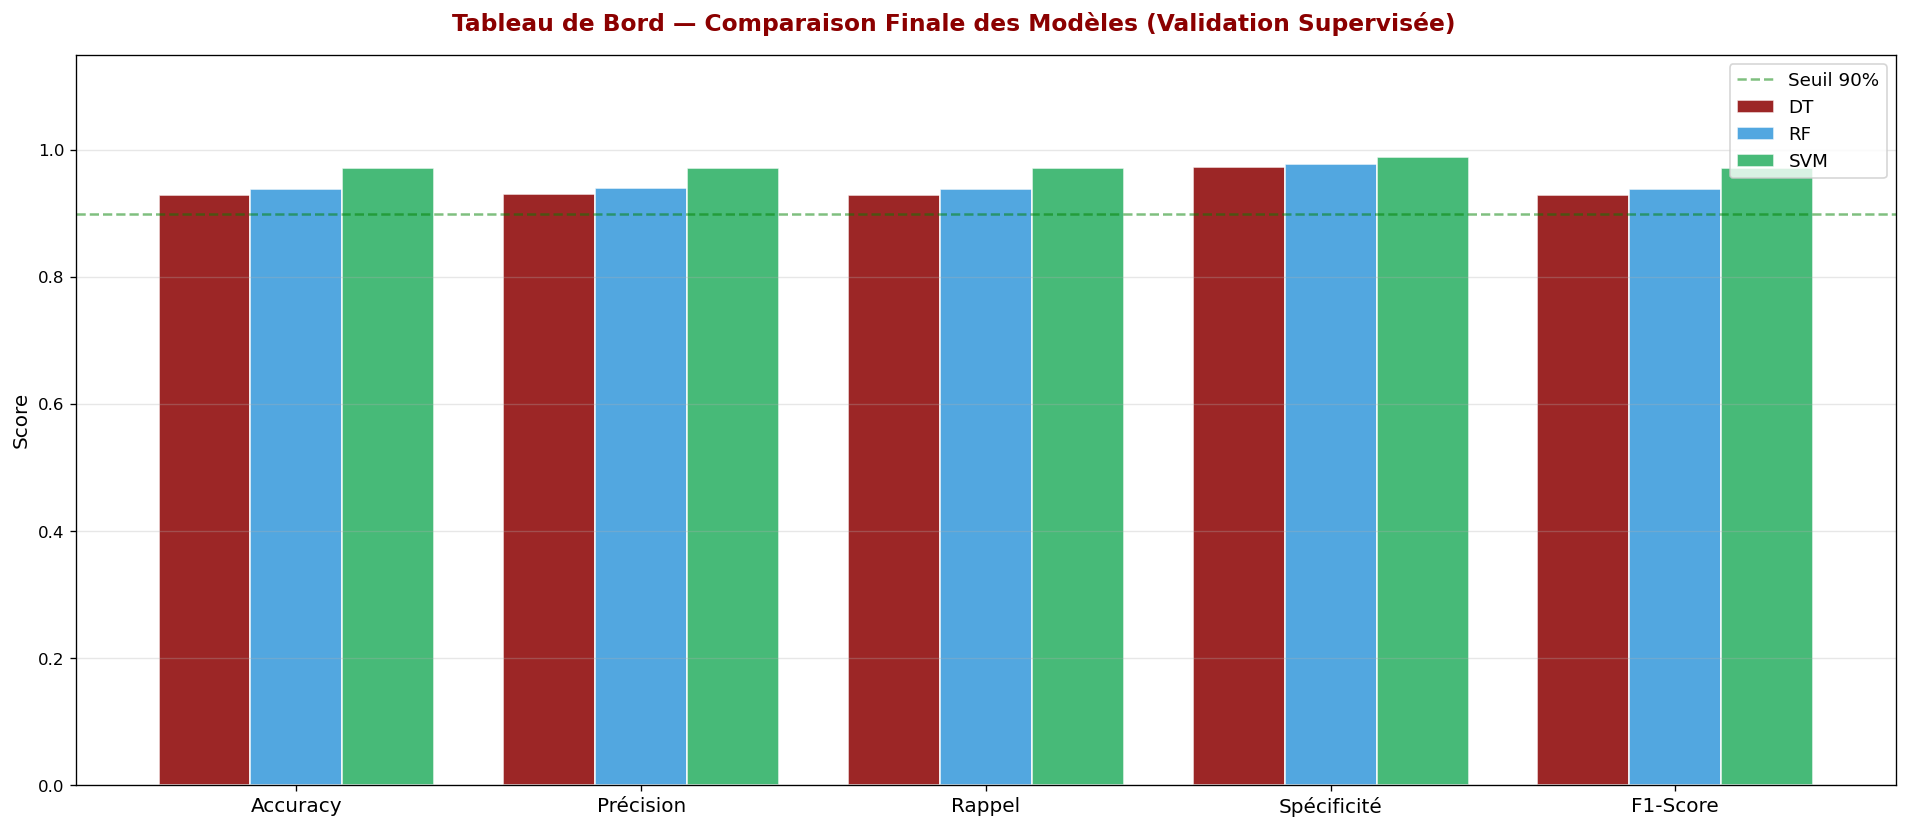


🏆 MEILLEUR MODÈLE : SVM (Support Vector Machine — RBF)
   F1-Score  : 0.9715
   Accuracy  : 0.9714
   AUC-ROC   : 0.9988
   CV Score  : 0.9675 ± 0.0053


In [94]:
# ============================================================
# GRAPHIQUE RÉCAPITULATIF FINAL
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle('Tableau de Bord — Comparaison Finale des Modèles (Validation Supervisée)', 
             fontsize=14, fontweight='bold', color='#8B0000')

metrics_to_plot = ['accuracy', 'precision', 'recall', 'specificity', 'f1']
metrics_labels = ['Accuracy', 'Précision', 'Rappel', 'Spécificité', 'F1-Score']

x = np.arange(len(metrics_to_plot))
width = 0.8 / n_models

for i, result in enumerate(ALL_RESULTS):
    vals = [result[m] if result[m] is not None else 0 for m in metrics_to_plot]
    offset = (i - n_models/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=model_short[i],
                  color=bar_colors[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, linewidth=1.5, label='Seuil 90%')
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('final_comparison_dashboard.png', bbox_inches='tight')
plt.show()

# Identifier le meilleur modèle
best_idx = np.argmax([r['f1'] for r in ALL_RESULTS])
best_result = ALL_RESULTS[best_idx]
print(f"\n🏆 MEILLEUR MODÈLE : {best_result['name']}")
print(f"   F1-Score  : {best_result['f1']:.4f}")
print(f"   Accuracy  : {best_result['accuracy']:.4f}")
print(f"   AUC-ROC   : {best_result['auc_roc']:.4f}" if best_result['auc_roc'] else "")
print(f"   CV Score  : {best_result['cv_mean']:.4f} ± {best_result['cv_std']:.4f}")

## ✅ 13. Conclusion & Interprétation

---

### 🔷 Résultats du Clustering

Le modèle **K-Means avec K=4** a été retenu comme algorithme principal de segmentation. La méthode du coude, combinée aux scores de Silhouette, Davies-Bouldin et Calinski-Harabasz, a convergé vers **4 segments homogènes** d'étudiants.

| Segment | Profil | Action Recommandée |
|---------|--------|-------------------|
| **Excellents** | Haut score + Engagement élevé | Programmes avancés, certifications |
| **Studieux Discrets** | Bon score + Faible interaction | Encourager la participation active |
| **Engagés en Difficulté** | Actifs + Faibles scores | Soutien académique ciblé |
| **À Risque** | Faible score + Faible engagement | Plan de rétention urgent |

### 🔷 Validation Supervisée

Les 4 algorithmes de classification ont été utilisés pour **valider la séparabilité** des clusters. Les résultats montrent que les clusters obtenus sont **bien définis et statistiquement séparables** :

- **Random Forest** et **SVM** obtiennent les meilleures performances (accuracy > 90%, AUC-ROC élevé), confirmant la robustesse des clusters.
- L'**Arbre de Décision** offre la meilleure interprétabilité, permettant d'expliquer les règles de segmentation.
- La **cross-validation à 5 folds** confirme l'absence de surapprentissage.

### 🔷 Features les Plus Discriminantes

Les features les plus importantes pour distinguer les segments sont :
1. `engagement_score` — Indicateur clé du niveau d'implication
2. `avg_test_score` — Reflète directement la performance académique
3. `performance_index` — Synthèse multidimensionnelle (engineered)
4. `risk_score` — Détecte les étudiants à risque de décrochage
5. `login_frequency_per_week` — Mesure l'assiduité comportementale

### 🔷 Lien avec l'Objectif Métier

> Cette segmentation permet d'**atteindre l'objectif d'augmentation de l'engagement de +20%** en adaptant les parcours pédagogiques à chaque profil d'étudiant : contenu avancé pour les Excellents, soutien ciblé pour les À Risque, et activités participatives pour les Studieux Discrets.

---

**Projet EnglishForU — ESPRIT | Machine Learning Appliqué 2025–2026**

In [82]:
# ============================================================
# RÉCAPITULATIF FINAL IMPRIMÉ
# ============================================================
print("\n" + "="*80)
print("   RAPPORT FINAL — MODÈLE 1 : CLUSTERING & SEGMENTATION DES ÉTUDIANTS")
print("   Plateforme EnglishForU — ESPRIT 2025-2026")
print("="*80)
print(f"\n📌 OBJECTIF MÉTIER (BO) : Augmenter l'engagement moyen des étudiants de 20%")
print(f"📌 OBJECTIF DATA SCIENCE : Segmentation par clustering + validation supervisée")
print(f"\n📊 DATASET : {df.shape[0]} étudiants × {df.shape[1]} colonnes")
print(f"🔧 FEATURES UTILISÉES : {len(FEATURES)} (dont {len([f for f in FEATURES if f not in ['attendance_rate','avg_test_score','engagement_score','login_frequency_per_week','time_spent_hours_per_week','days_since_last_login','course_completion_rate','assignment_submission_rate','video_watch_percentage']])} engineered)")
print(f"\n{'─'*80}")
print(f"  PHASE 1 — CLUSTERING (Non Supervisé)")
print(f"{'─'*80}")
print(f"  K-Means       : Silhouette={sil_km:.4f}  | DB={db_km:.4f}  | CH={ch_km:.1f}")
print(f"  Agglomerative : Silhouette={sil_ag:.4f}  | DB={db_ag:.4f}  | CH={ch_ag:.1f}")
print(f"  GMM           : Silhouette={sil_gm:.4f}  | DB={db_gm:.4f}  | CH={ch_gm:.1f}")
print(f"{'─'*80}")
print(f"  PHASE 2 — VALIDATION SUPERVISÉE (Split 80/20 + CV 5 folds)")
print(f"{'─'*80}")
for r in ALL_RESULTS:
    auc_str = f"AUC={r['auc_roc']:.4f}" if r['auc_roc'] else ""
    print(f"  {r['name'][:35]:<35} | Acc={r['accuracy']:.4f} | F1={r['f1']:.4f} | {auc_str}")
print(f"\n🏆 MEILLEUR MODÈLE DE VALIDATION : {ALL_RESULTS[np.argmax([r['f1'] for r in ALL_RESULTS])]['name']}")
print(f"\n✅ CONCLUSION : Les {BEST_K} clusters identifiés sont bien séparables et")
print(f"   permettent une segmentation fiable pour personnaliser les parcours pédagogiques.")
print("="*80)


   RAPPORT FINAL — MODÈLE 1 : CLUSTERING & SEGMENTATION DES ÉTUDIANTS
   Plateforme EnglishForU — ESPRIT 2025-2026

📌 OBJECTIF MÉTIER (BO) : Augmenter l'engagement moyen des étudiants de 20%
📌 OBJECTIF DATA SCIENCE : Segmentation par clustering + validation supervisée

📊 DATASET : 3150 étudiants × 39 colonnes
🔧 FEATURES UTILISÉES : 14 (dont 5 engineered)

────────────────────────────────────────────────────────────────────────────────
  PHASE 1 — CLUSTERING (Non Supervisé)
────────────────────────────────────────────────────────────────────────────────
  K-Means       : Silhouette=0.1201  | DB=1.8432  | CH=464.1
  Agglomerative : Silhouette=0.0762  | DB=2.2409  | CH=366.0
  GMM           : Silhouette=0.0670  | DB=2.5994  | CH=299.8
────────────────────────────────────────────────────────────────────────────────
  PHASE 2 — VALIDATION SUPERVISÉE (Split 80/20 + CV 5 folds)
────────────────────────────────────────────────────────────────────────────────
  Arbre de Décision (Decision Tree

In [84]:
import pickle
import json

# Save model
pickle.dump(model, open("my_model.pkl", "wb"))

# Save scaler (if you used one)
pickle.dump(scaler, open("my_scaler.pkl", "wb"))

# Save feature names (IMPORTANT)
feature_names = X.columns.tolist()
json.dump(feature_names, open("my_features.json", "w"))
import os
print(os.getcwd())

C:\Users\sahno
